In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import warnings, os, gc, re
import matplotlib.pyplot as plt
import swifter
import psutil

# from plotnine import ggplot, aes, geom_line
from plotnine import *
# import pygal as pg
%matplotlib inline

import missingno as msno

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [2]:
path, dirs, files = next(os.walk("chunks/"))
directory = 'chunks/'
file_count = len(files)
year_start = 2013
year_end = 2020

In [3]:
# # codes in ILLNESS*_CODE that are not ICD-10 codes
# not_icd = ['MCP01', 'NSD01', 'P0000', 'P0001', 'ANC01', 'ANC02']

# #icd-10 philhealth list - 2017
# df_icd10 = pd.read_excel(os.path.join(directory, 'ICD10 philhealth.xlsx'))
# df_icd10 = df_icd10.set_axis(['ILLNESS1_CODE','DESCRIPTION','GROUP','CASE_RATE','PROFESSIONAL_FEE', \
#                               'HEALTH_CARE_INST_FEE'], axis=1, inplace=False)

# #procedures philhealth list - 2015
# df_procs = pd.read_excel(os.path.join(directory, 'Procedures philhealth.xlsx'))
# df_procs = df_procs.set_axis(['ILLNESS1_CODE','DESCRIPTION','CASE_RATE','PROFESSIONAL_FEE', \
#                               'HEALTH_CARE_INST_FEE'], axis=1, inplace=False)

In [3]:
# count number of rows
from itertools import (takewhile,repeat)
def rawincount(filename):
    f = open(filename, 'rb')
    bufgen = takewhile(lambda x: x, (f.raw.read(1024*1024) for _ in repeat(None)))
    return sum( buf.count(b'\n') for buf in bufgen )

# compute for memory usage
def usage():
    process = psutil.Process(os.getpid())
    return process.memory_info()[0] / float(2 ** 20)

In [4]:
# counts per single categorical field
def group_categs(dframe, col_name_grp, ren_cols, total_year):
    df = dframe.groupby([col_name_grp]).size().sort_values(ascending=False).to_frame().reset_index() \
                .set_axis([ren_cols, 'Freq.'], axis=1, inplace=False)
    df['Percent'] = ((df['Freq.'].values/total_year)*100)
    df['Freq.'] = df.swifter.progress_bar(False).apply(lambda x: '{:,}'.format(x['Freq.']),axis=1)
    df['Percent'] = df.swifter.progress_bar(False).apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    return df

# reference: https://bip.weizmann.ac.il/course/python/PyMOTW/PyMOTW/docs/gc/index.html
import pprint
def garbage_collector():
    for i in range(4):
        print('Collecting %d ...' % i)
        n = gc.collect()
        print('Unreachable objects:', n)
        print('Remaining Garbage:',) 
        pprint.pprint(gc.garbage)
        print

# 2013

### Read Input File

In [6]:
year_upd = 2013
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO NCR SOUTH,"LAS PIÑAS DOCTORS HOSPITAL, INC.",CORPORATE,LEVEL 3 HOSPITAL,FOURTH DIST.,LAS PINAS CITY,INFORMAL ECONOMY,INFORMAL SECTOR,FOURTH DIST.,LAS PINAS CITY,...,NaN,-1,NaN,NaN,NaN,NaN,22398.9500,4300.0000,2014-02-19,2013-12-04
1,PRO CAR,BAGUIO GENERAL HOSPITAL AND MEDICAL CENTER,DOH,LEVEL 3 HOSPITAL,BENGUET,BAGUIO CITY,FORMAL ECONOMY,PRIVATE,BENGUET,BAGUIO CITY,...,NaN,-1,NaN,NaN,NaN,NaN,15000.0000,15000.0000,2013-11-05,2013-10-03
2,PRO V,OUR LADY OF LOURDES HOSPITAL,CORPORATE,LEVEL 2 HOSPITAL,CAMARINES NORTE,DAET,SPONSORED,SPONSORED,CAMARINES NORTE,DAET,...,NaN,-1,NaN,NaN,NaN,NaN,10500.0000,15000.0000,2014-01-17,2013-11-27
3,PRO XI,DAVAO DOCTORS HOSPITAL,CORPORATE,LEVEL 3 HOSPITAL,DAVAO DEL SUR,DAVAO CITY,FORMAL ECONOMY,PRIVATE,DAVAO DEL SUR,DAVAO CITY,...,NaN,-1,NaN,NaN,NaN,NaN,16338.1300,5235.8700,2014-01-08,2013-11-13
4,PRO IIIA,MANABAT MATERNITY AND GENERAL HOSPITAL,SINGLE PROPRIETORSHIP,LEVEL 1 HOSPITAL,PAMPANGA,SANTO TOMAS,SPONSORED,SPONSORED,PAMPANGA,SANTO TOMAS,...,NaN,-1,NaN,NaN,NaN,NaN,18572.0000,8400.0000,2013-08-12,2013-07-04


In [7]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,11206,0.1932
1,No. of Rows with ACTUAL_AMT > 10M,123,0.0021
2,No. of Rows with ACTUAL_AMT < 1M,5786960,99.7703
3,No. of Rows with ACTUAL_AMT < 500k,5780483,99.6586
4,No. of Rows with ACTUAL_AMT < 300k,5769102,99.4624
5,No. of Rows with ACTUAL_AMT < 200k,5751496,99.1589
6,No. of Rows with ACTUAL_AMT < 100k,5672522,97.7973
7,No. of Rows with ACTUAL_AMT < 50k,5439939,93.7875
8,No. of Rows with ACTUAL_AMT <= 500,427147,7.3642
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,421613,7.2688


In [8]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [9]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
Unnamed: 0,
0,22398.9500
1,15000.0000
2,10500.0000
3,16338.1300
4,18572.0000


In [10]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [11]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [12]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [13]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [14]:
# write spreadsheets above
writer.save()

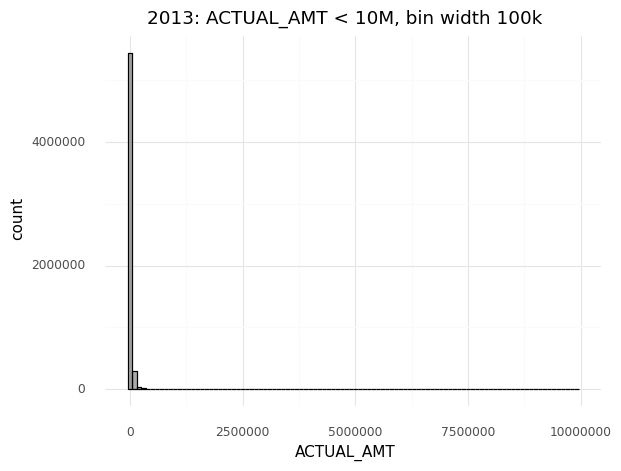

<ggplot: (121961263924)>

In [15]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

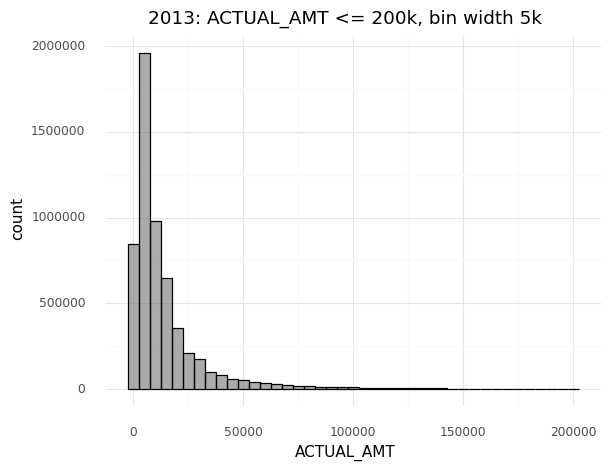

<ggplot: (121961440552)>

In [16]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

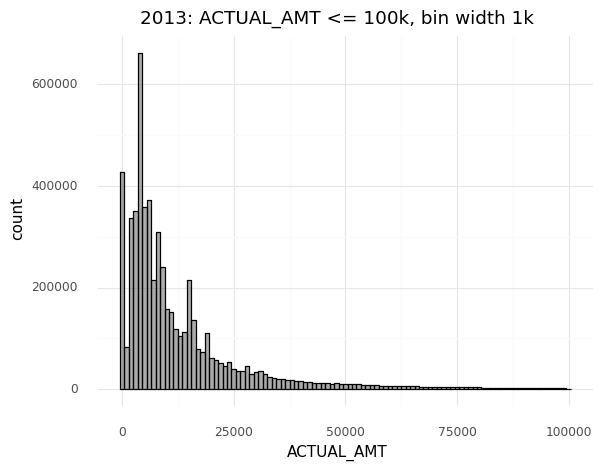

<ggplot: (121961438088)>

In [17]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

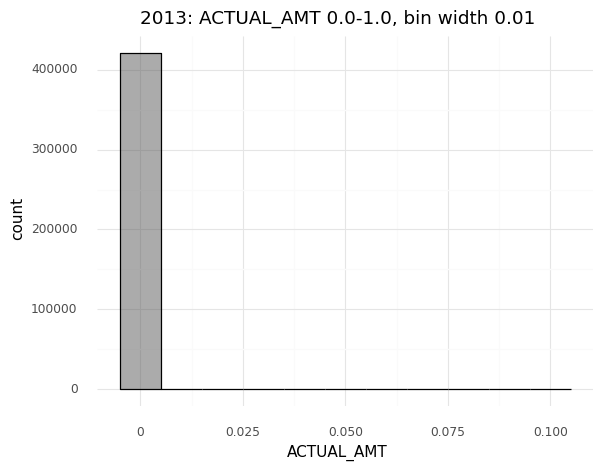

<ggplot: (121961409434)>

In [18]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

<AxesSubplot:>

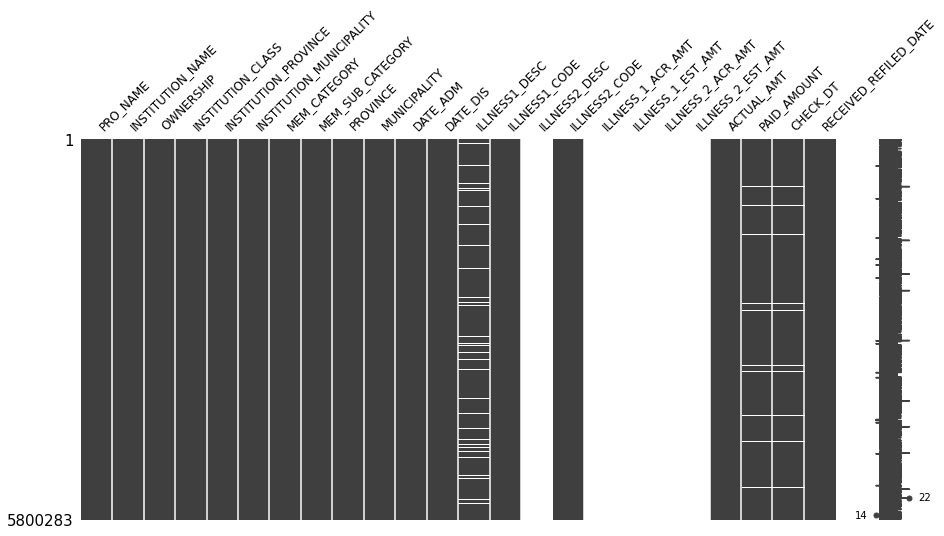

In [19]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

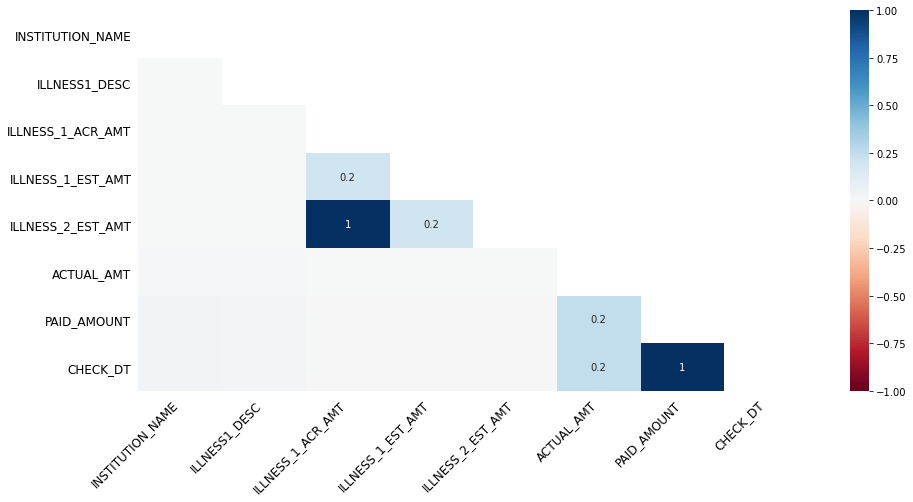

In [20]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

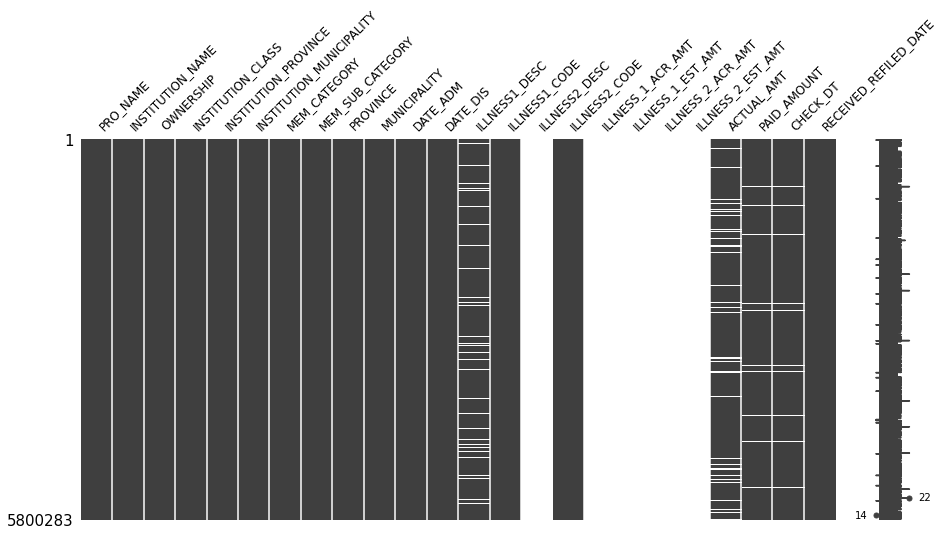

In [21]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

<AxesSubplot:>

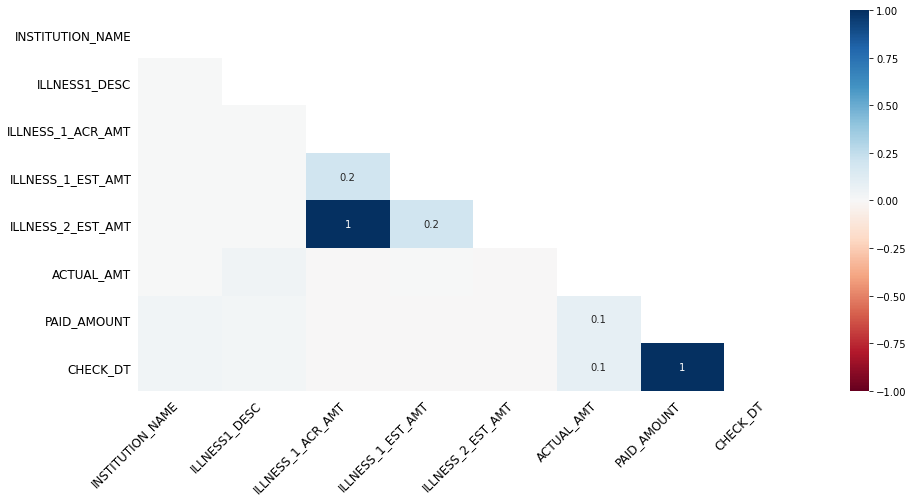

In [22]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [23]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

# 2014

### Read Input File

In [24]:
year_upd = 2014
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO NCR SOUTH,THE MEDICAL CITY,CORPORATE,LEVEL 3 HOSPITAL,SECOND DISTRICT,PASIG CITY,INFORMAL ECONOMY,INFORMAL SECTOR,SECOND DISTRICT,PASIG CITY,...,NaN,-1,19000.0000,19000.0000,NaN,0.0000,0.0000,19000.0000,2014-04-04,2014-02-24
1,PRO NCR NORTH,FR CATAQUIZ MATERNITY CLINIC,SINGLE PROPRIETORSHIP,MCP PROVIDER,THIRD DIST.,NAVOTAS,FORMAL ECONOMY,PRIVATE,THIRD DIST.,NAVOTAS,...,NaN,-1,8000.0000,8000.0000,NaN,0.0000,0.0000,8000.0000,2014-07-30,2014-07-11
2,PRO NCR SOUTH,MAKATI MEDICAL CENTER,CORPORATE,LEVEL 3 HOSPITAL,FOURTH DIST.,MAKATI CITY,INFORMAL ECONOMY,INFORMAL SECTOR,FOURTH DIST.,MAKATI CITY,...,NaN,-1,4000.0000,4000.0000,NaN,0.0000,6804.3000,4000.0000,2014-03-07,2014-01-20
3,PRO XI,"SAN PEDRO HOSPITAL OF DAVAO CITY, INC.",CORPORATE,LEVEL 3 HOSPITAL,DAVAO DEL SUR,DAVAO CITY,INFORMAL ECONOMY,OWP,DAVAO DEL SUR,DAVAO CITY,...,NaN,-1,16000.0000,16000.0000,NaN,0.0000,0.0000,16000.0000,2014-09-23,2014-08-07
4,PRO X,MALAYBALAY POLYMEDIC GENERAL HOSPITAL,SINGLE PROPRIETORSHIP,LEVEL 2 HOSPITAL,BUKIDNON,MALAYBALAY,FORMAL ECONOMY,GOVERNMENT,BUKIDNON,MALAYBALAY,...,NaN,-1,6800.0000,6800.0000,NaN,0.0000,0.0000,6800.0000,2014-12-16,2014-11-10


In [25]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,2390,0.0375
1,No. of Rows with ACTUAL_AMT > 10M,115,0.0018
2,No. of Rows with ACTUAL_AMT < 1M,6376152,99.9438
3,No. of Rows with ACTUAL_AMT < 500k,6373949,99.9092
4,No. of Rows with ACTUAL_AMT < 300k,6370496,99.8551
5,No. of Rows with ACTUAL_AMT < 200k,6364712,99.7644
6,No. of Rows with ACTUAL_AMT < 100k,6338023,99.3461
7,No. of Rows with ACTUAL_AMT < 50k,6255721,98.0560
8,No. of Rows with ACTUAL_AMT <= 500,4708383,73.8021
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,4706337,73.7700


In [26]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [27]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
Unnamed: 0,
0,0.0000
1,0.0000
2,6804.3000
3,0.0000
4,0.0000


In [28]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [29]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [30]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [31]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [32]:
# write spreadsheets above
writer.save()

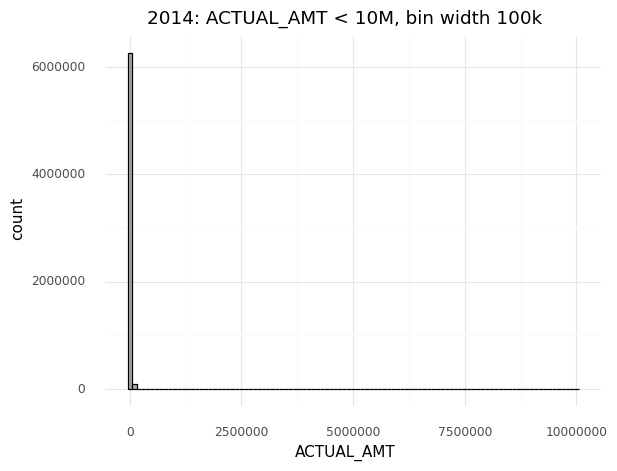

<ggplot: (121961403402)>

In [33]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

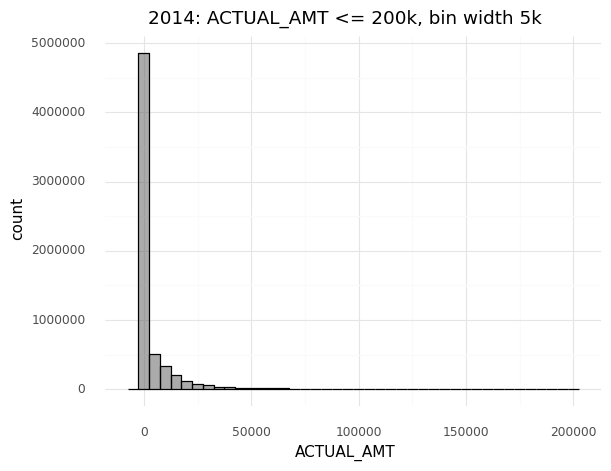

<ggplot: (121961387852)>

In [34]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

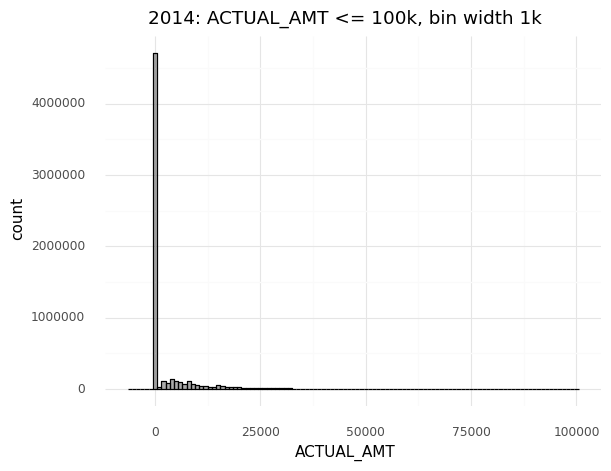

<ggplot: (121972079318)>

In [35]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

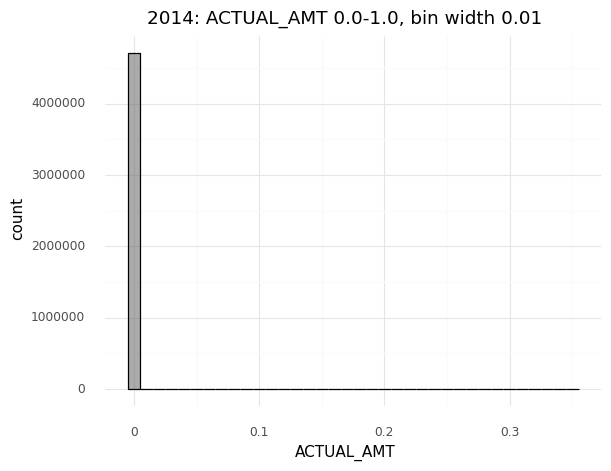

<ggplot: (121961367266)>

In [36]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

<AxesSubplot:>

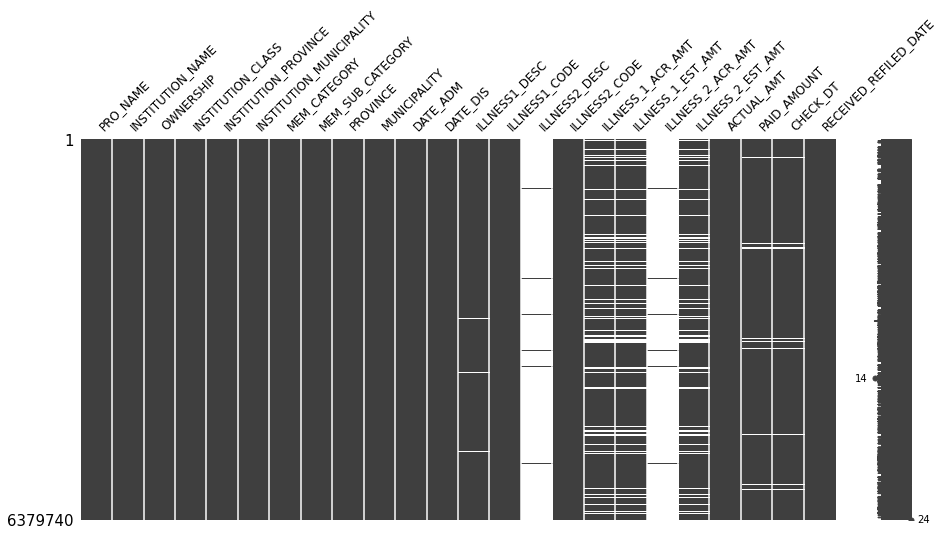

In [37]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

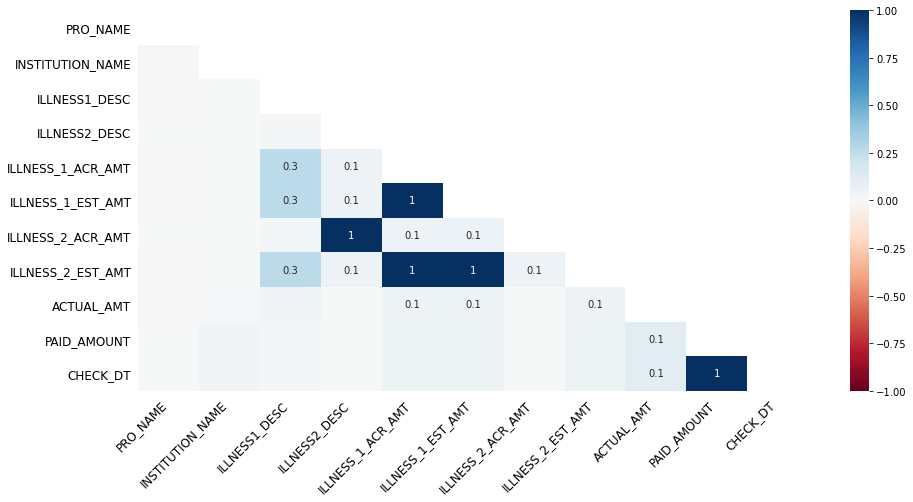

In [38]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

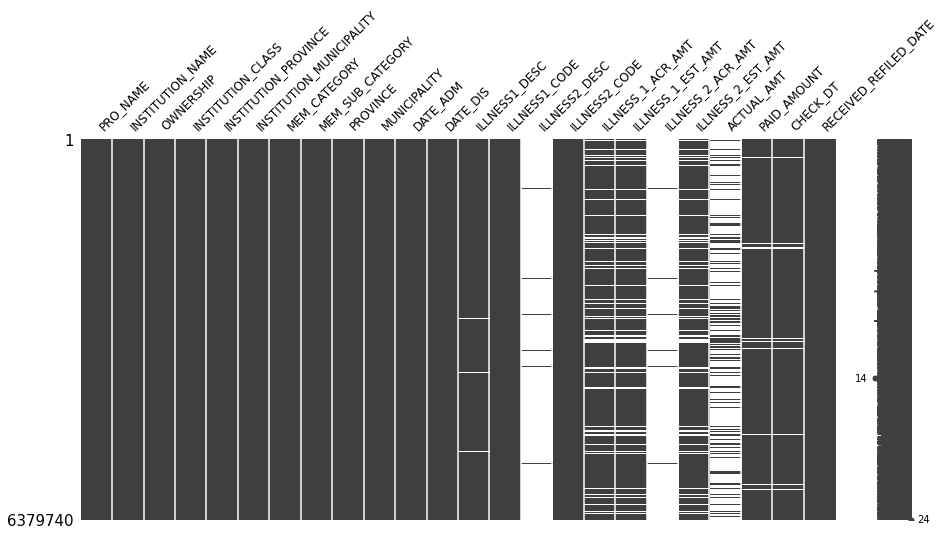

In [39]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

<AxesSubplot:>

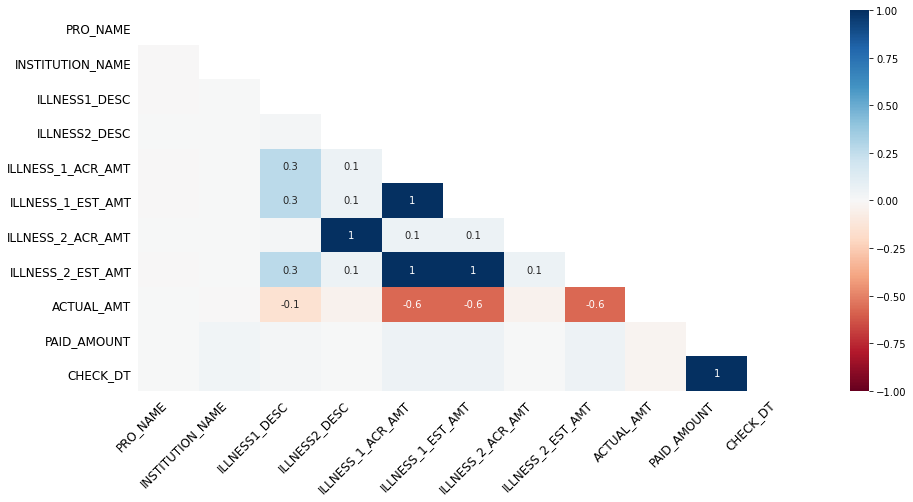

In [40]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [41]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

# 2015

### Read Input File

In [42]:
year_upd = 2015
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO NCR CENTRAL,MARIKINA VALLEY MEDICAL CENTER,CORPORATE,LEVEL 2 HOSPITAL,SECOND DISTRICT,MARIKINA CITY,FORMAL ECONOMY,PRIVATE,SECOND DISTRICT,MARIKINA CITY,...,NaN,-1,10540.0000,10540.0000,NaN,0.0000,0.0000,10540.0000,2015-12-03,2015-11-09
1,PRO VI,ALEOSAN DISTRICT HOSPITAL,LGU,LEVEL 1 HOSPITAL,ILOILO,ALIMODIAN,INDIGENT,INDIGENT,ILOILO,ALIMODIAN,...,NaN,-1,15000.0000,15000.0000,NaN,0.0000,0.0000,15000.0000,2016-02-12,2015-12-11
2,PRO XI,DAVAO DOCTORS HOSPITAL,CORPORATE,LEVEL 3 HOSPITAL,DAVAO DEL SUR,DAVAO CITY,LIFETIME MEMBER,LIFETIME MEMBER,DAVAO DEL SUR,DAVAO CITY,...,NaN,-1,13000.0000,13000.0000,NaN,0.0000,17057.4100,13000.0000,2015-09-16,2015-09-07
3,PRO IVB,NORTHERN PALAWAN PROVINCIAL HOSPITAL,GOVERNMENT OWNED,LEVEL 1 HOSPITAL,PALAWAN,TAYTAY,INDIGENT,INDIGENT,PALAWAN,TAYTAY,...,NaN,-1,6000.0000,6000.0000,NaN,0.0000,0.0000,6000.0000,2015-07-28,2015-06-30
4,PRO IVB,OSPITAL NG LIPA,LGU,LEVEL 1 HOSPITAL,BATANGAS,LIPA CITY,SPONSORED,SPONSORED,BATANGAS,LIPA CITY,...,NaN,-1,15000.0000,15000.0000,NaN,0.0000,0.0000,15000.0000,2016-01-27,2015-12-03


In [43]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,167,0.0020
1,No. of Rows with ACTUAL_AMT > 10M,113,0.0014
2,No. of Rows with ACTUAL_AMT < 1M,8288668,99.9850
3,No. of Rows with ACTUAL_AMT < 500k,8286849,99.9631
4,No. of Rows with ACTUAL_AMT < 300k,8284292,99.9322
5,No. of Rows with ACTUAL_AMT < 200k,8279537,99.8748
6,No. of Rows with ACTUAL_AMT < 100k,8254287,99.5703
7,No. of Rows with ACTUAL_AMT < 50k,8174494,98.6077
8,No. of Rows with ACTUAL_AMT <= 500,6355690,76.6678
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,6354115,76.6488


In [44]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [45]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
Unnamed: 0,
0,0.0000
1,0.0000
2,17057.4100
3,0.0000
4,0.0000


In [46]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [47]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [48]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [49]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [50]:
# write spreadsheets above
writer.save()

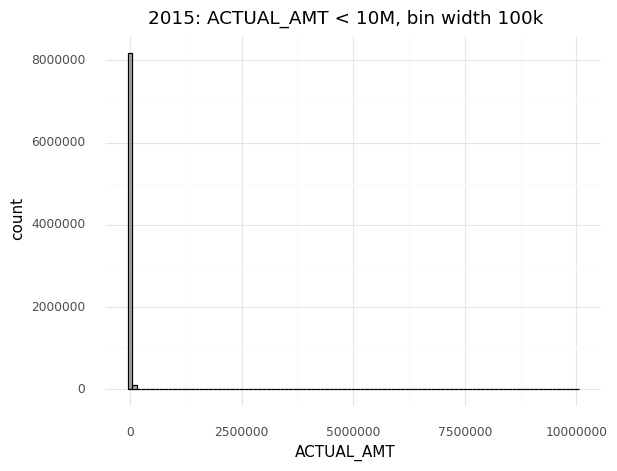

<ggplot: (121972028212)>

In [51]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

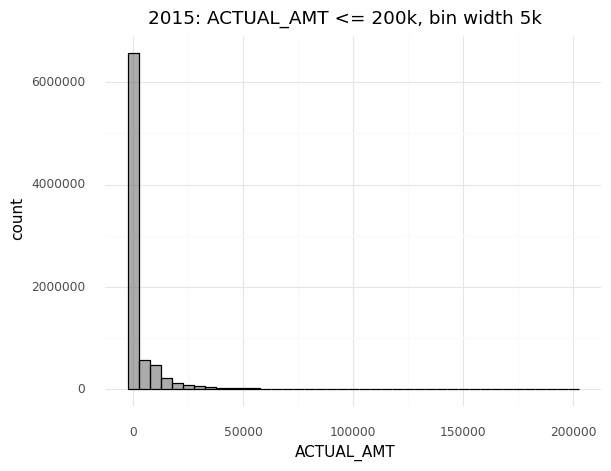

<ggplot: (121979211361)>

In [52]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

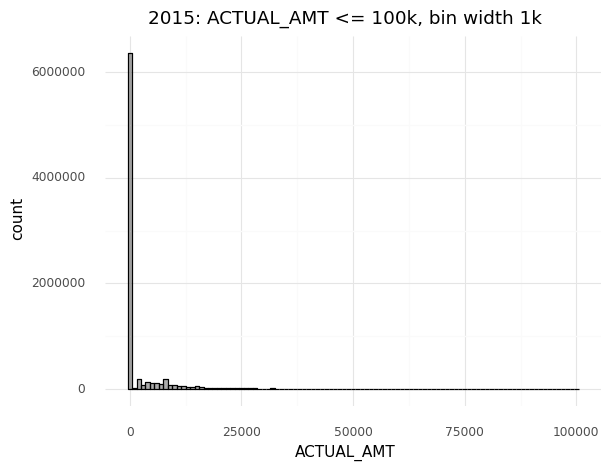

<ggplot: (121972079987)>

In [53]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

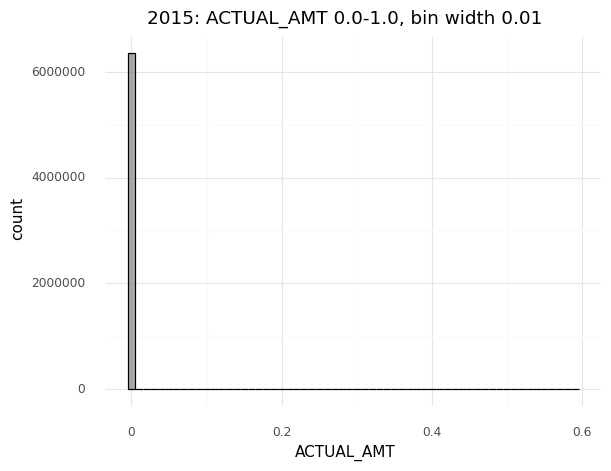

<ggplot: (121972114312)>

In [54]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

<AxesSubplot:>

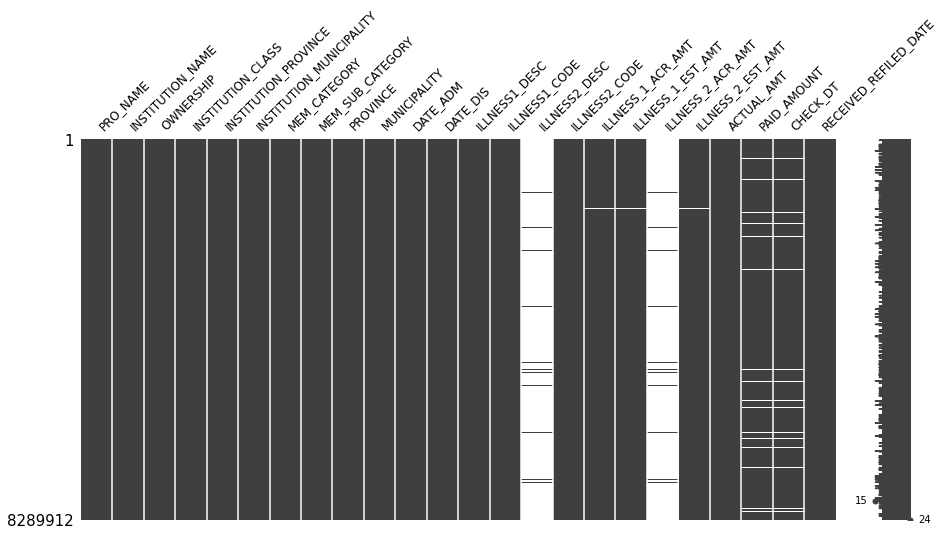

In [55]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

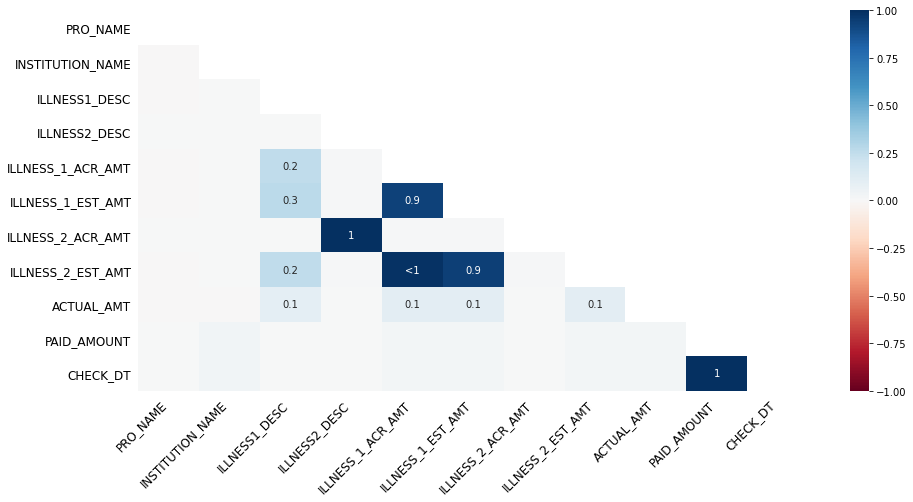

In [56]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

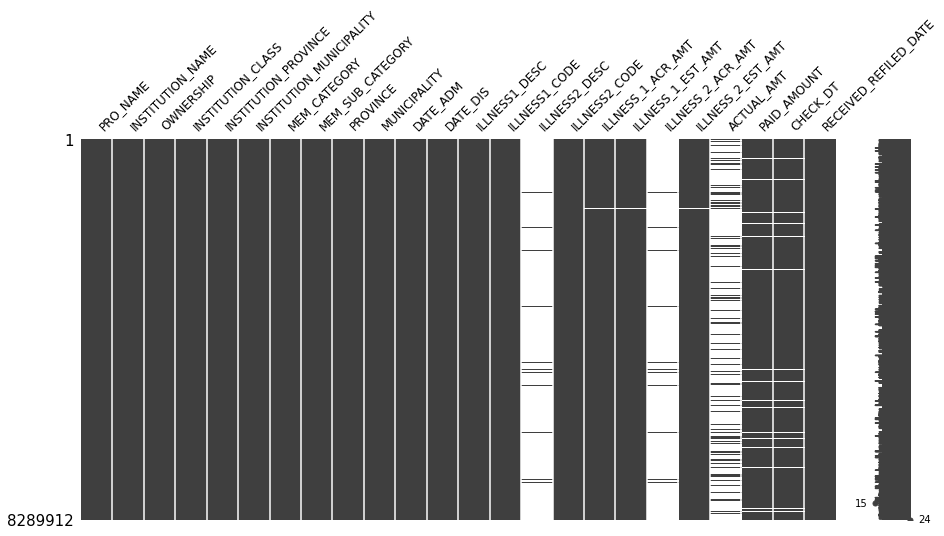

In [57]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

<AxesSubplot:>

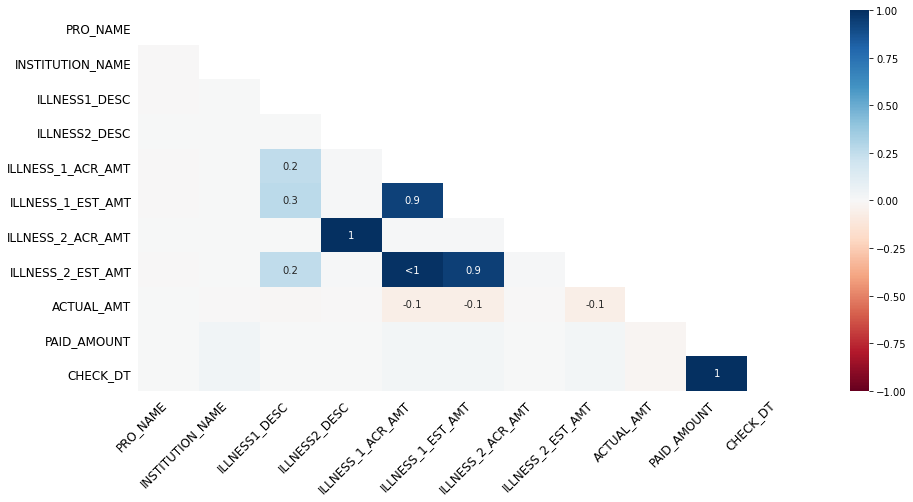

In [58]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [61]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

NameError: name 'df1' is not defined

# 2016

### Read Input File

In [5]:
year_upd = 2016
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO I,REGION I MEDICAL CENTER,DOH,LEVEL 3 HOSPITAL,PANGASINAN,DAGUPAN CITY,SPONSORED,SPONSORED,PANGASINAN,DAGUPAN CITY,...,NaN,-1,1750.0000,1750.0000,NaN,0.0000,1.0000,1550.0000,2017-01-05,2016-11-23
1,PRO CARAGA,ADELA SERRA TY MEMORIAL MEDICAL CENTER,DOH,LEVEL 1 HOSPITAL,SURIGAO DEL SUR,TANDAG CITY,SPONSORED,SPONSORED,SURIGAO DEL SUR,TANDAG CITY,...,NaN,-1,31140.0000,31140.0000,NaN,0.0000,0.0000,31140.0000,2016-07-28,2016-07-08
2,PRO VII,CEBU PROVINCIAL HOSPITAL (BOGO CITY),PROVINCIAL,LEVEL 1 HOSPITAL,CEBU,BOGO,INDIGENT,INDIGENT,CEBU,BOGO,...,NaN,-1,15000.0000,15000.0000,NaN,0.0000,15000.0000,15000.0000,2017-09-08,2016-09-07
3,PRO IIIA,CENTRAL LUZON DOCTORS' HOSPITAL,CORPORATE,LEVEL 3 HOSPITAL,TARLAC,TARLAC,INFORMAL ECONOMY,OWP,TARLAC,TARLAC,...,NaN,-1,6000.0000,6000.0000,NaN,0.0000,25191.2700,6000.0000,2016-09-20,2016-06-28
4,PRO I,WESTERN PANGASINAN DISTRICT HOSPITAL,LGU,LEVEL 1 HOSPITAL,PANGASINAN,ALAMINOS,INDIGENT,INDIGENT,PANGASINAN,ALAMINOS,...,NaN,-1,4000.0000,4000.0000,NaN,0.0000,0.0000,4000.0000,2016-07-08,2016-06-06


In [6]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,25,0.0003
1,No. of Rows with ACTUAL_AMT > 10M,373,0.0038
2,No. of Rows with ACTUAL_AMT < 1M,9724909,99.9623
3,No. of Rows with ACTUAL_AMT < 500k,9718403,99.8954
4,No. of Rows with ACTUAL_AMT < 300k,9708169,99.7902
5,No. of Rows with ACTUAL_AMT < 200k,9690322,99.6067
6,No. of Rows with ACTUAL_AMT < 100k,9606929,98.7496
7,No. of Rows with ACTUAL_AMT < 50k,9369361,96.3076
8,No. of Rows with ACTUAL_AMT <= 500,4894537,50.3109
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,4613934,47.4266


In [7]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [8]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
Unnamed: 0,
0,1.0000
1,0.0000
2,15000.0000
3,25191.2700
4,0.0000


In [9]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [10]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [11]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [12]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [13]:
# write spreadsheets above
writer.save()

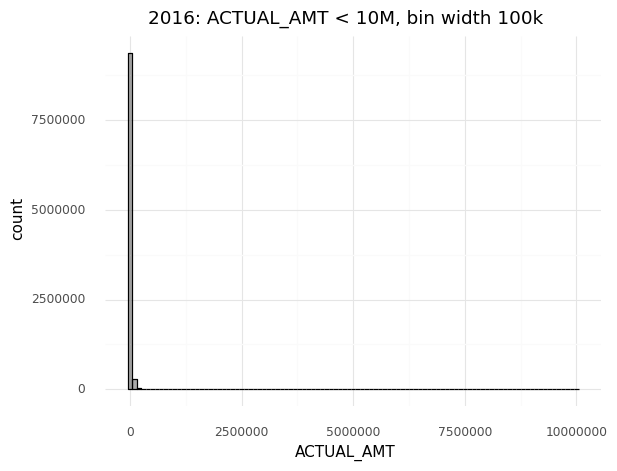

<ggplot: (136239651410)>

In [14]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

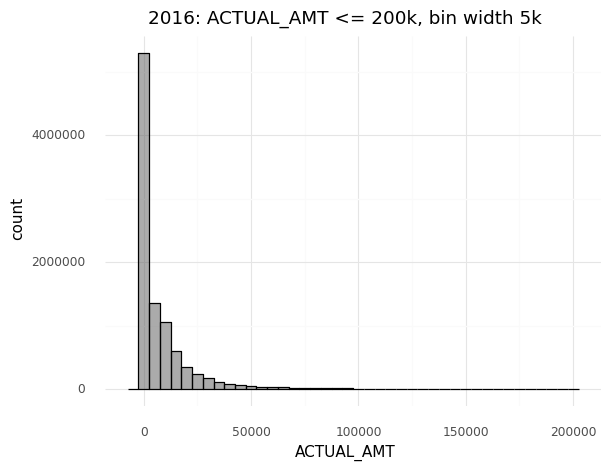

<ggplot: (136239631126)>

In [15]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

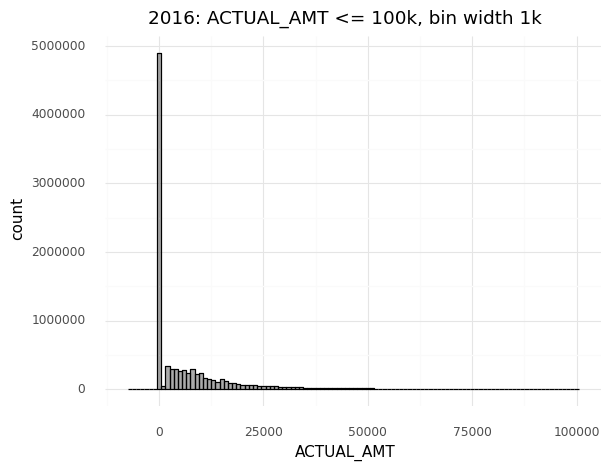

<ggplot: (136239979641)>

In [16]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

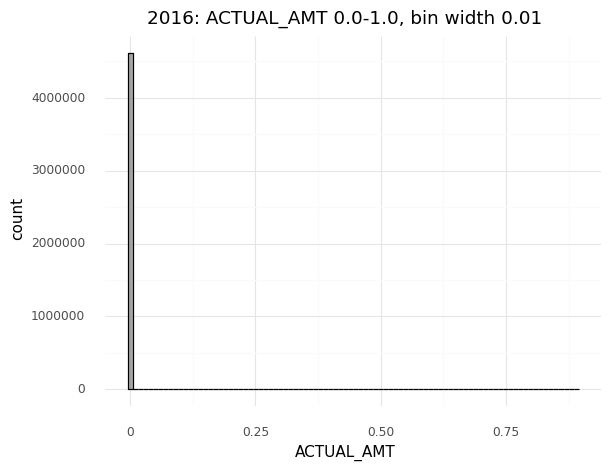

<ggplot: (136239796477)>

In [17]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

<AxesSubplot:>

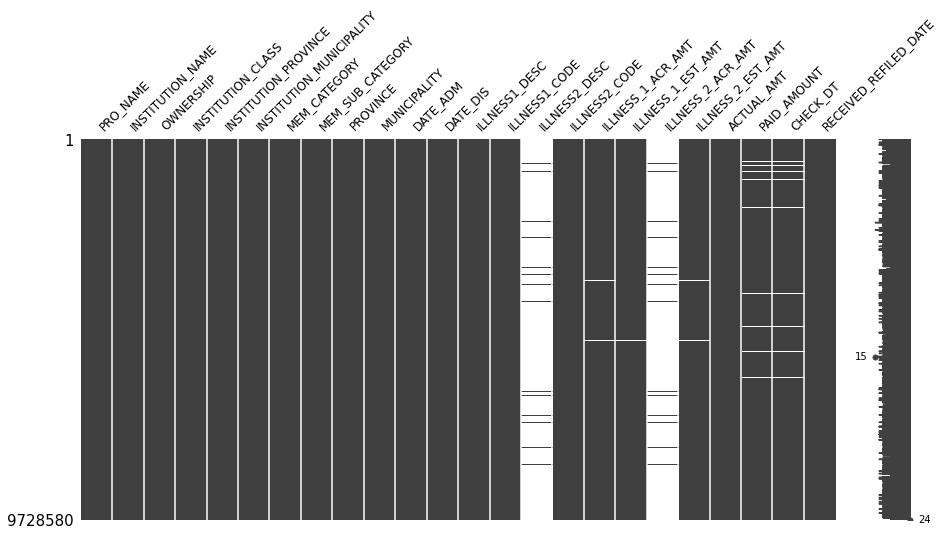

In [18]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

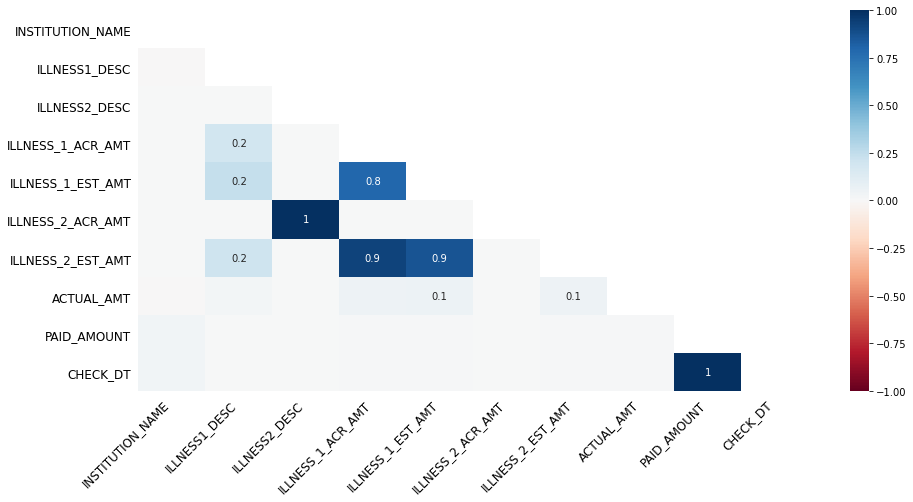

In [19]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

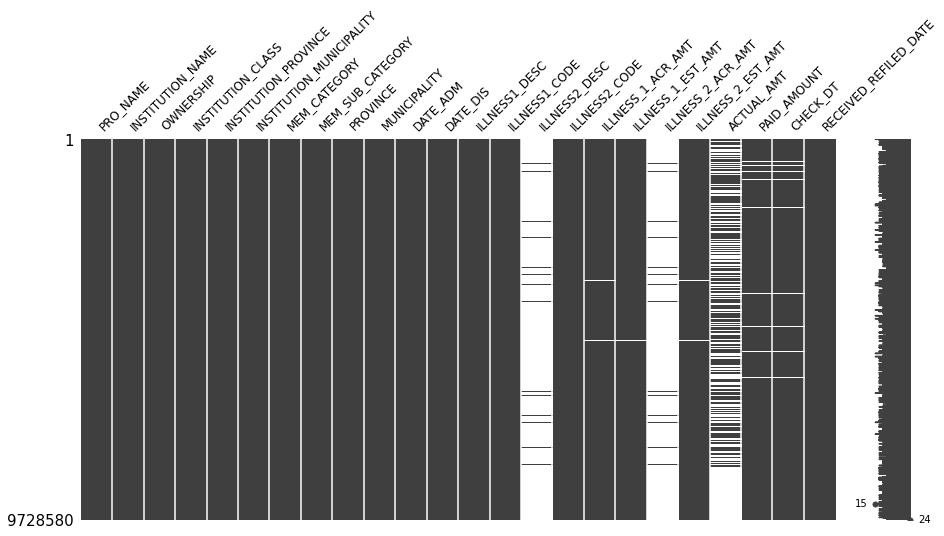

In [20]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

<AxesSubplot:>

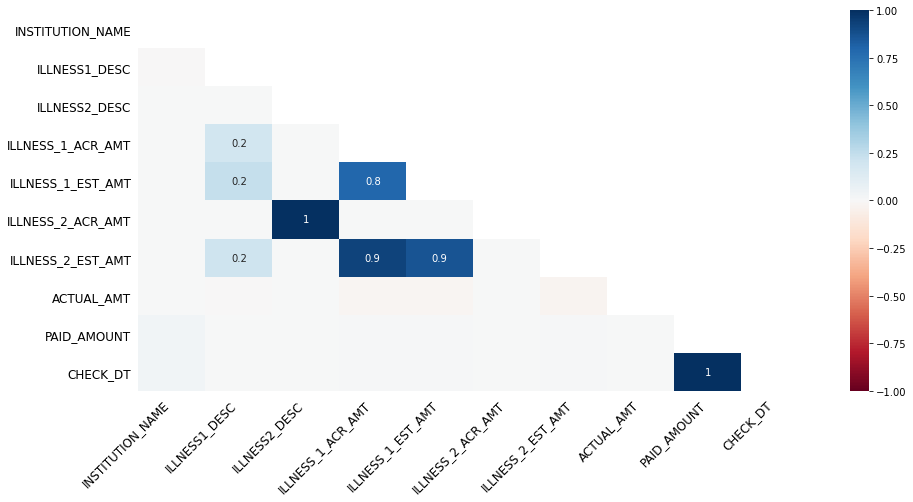

In [21]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [22]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

Unreachable objects: 13309
Remaining Garbage:
[]
Unreachable objects: 0
Remaining Garbage:
[]


# 2017

### Read Input File

In [23]:
year_upd = 2017
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO VII,VICENTE SOTTO MEMORIAL MEDICAL CENTER,DOH,LEVEL 3 HOSPITAL,CEBU,CEBU CITY,SENIOR CITIZEN,SENIOR CITIZEN,CEBU,CEBU CITY,...,NaN,-1,2600.0000,2600.0000,NaN,0.0000,2600.0000,2600.0000,2017-09-08,2017-03-28
1,PRO XII,"QUIJANO CLINIC & HOSPITAL, INC.",COOPERATIVE,LEVEL 1 HOSPITAL,SULTAN KUDARAT,TACURONG,FORMAL ECONOMY,GOVERNMENT,SULTAN KUDARAT,TACURONG,...,NaN,-1,32000.0000,32000.0000,NaN,0.0000,39766.6900,32000.0000,2017-09-12,2017-07-25
2,PRO I,BUGALLON RHU II BIRTHING HOME FACILITY,LGU,MCP PROVIDER,PANGASINAN,BUGALLON,FORMAL ECONOMY,GOVERNMENT,PANGASINAN,BUGALLON,...,NaN,-1,6500.0000,8000.0000,NaN,0.0000,2.0000,8000.0000,2017-10-14,2017-08-22
3,PRO IVB,OSPITAL NG PALAWAN,DOH,LEVEL 1 HOSPITAL,PALAWAN,PUERTO PRINCESA CITY,SPONSORED,SPONSORED,PALAWAN,PUERTO PRINCESA CITY,...,NaN,-1,15000.0000,15000.0000,NaN,0.0000,10104.0000,15000.0000,2017-08-30,2017-06-18
4,PRO NCR SOUTH,OSPITAL NG MAKATI,LGU,LEVEL 3 HOSPITAL,FOURTH DIST.,MAKATI CITY,FORMAL ECONOMY,PRIVATE,FOURTH DIST.,MAKATI CITY,...,"LIGATION OR TRANSECTION OF FALLOPIAN TUBE(S), ...",58600,19000.0000,19000.0000,4000.0000,4000.0000,23907.9400,19000.0000,2017-09-07,2017-08-04


In [24]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,3,0.0000
1,No. of Rows with ACTUAL_AMT > 10M,618,0.0061
2,No. of Rows with ACTUAL_AMT < 1M,10112262,99.9324
3,No. of Rows with ACTUAL_AMT < 500k,10099242,99.8037
4,No. of Rows with ACTUAL_AMT < 300k,10077354,99.5874
5,No. of Rows with ACTUAL_AMT < 200k,10041001,99.2281
6,No. of Rows with ACTUAL_AMT < 100k,9878642,97.6237
7,No. of Rows with ACTUAL_AMT < 50k,9435103,93.2405
8,No. of Rows with ACTUAL_AMT <= 500,1157202,11.4358
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,535593,5.2929


In [25]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [26]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
Unnamed: 0,
0,2600.0000
1,39766.6900
2,2.0000
3,10104.0000
4,23907.9400


In [27]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [28]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [29]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [30]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [31]:
# write spreadsheets above
writer.save()

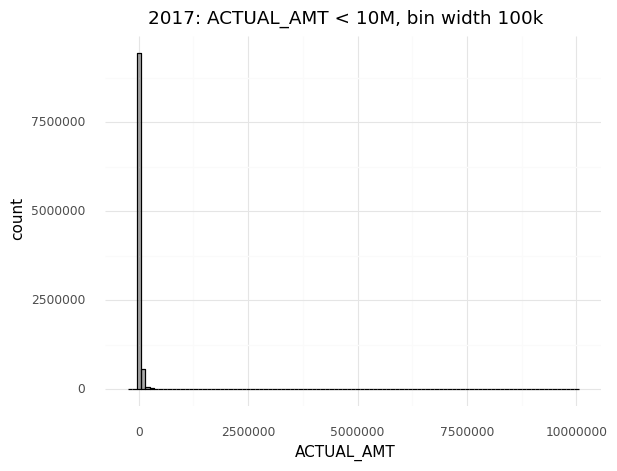

<ggplot: (136239770387)>

In [32]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

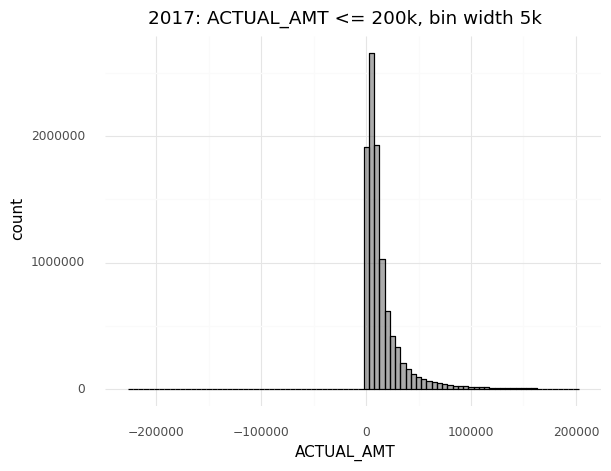

<ggplot: (136239757267)>

In [33]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

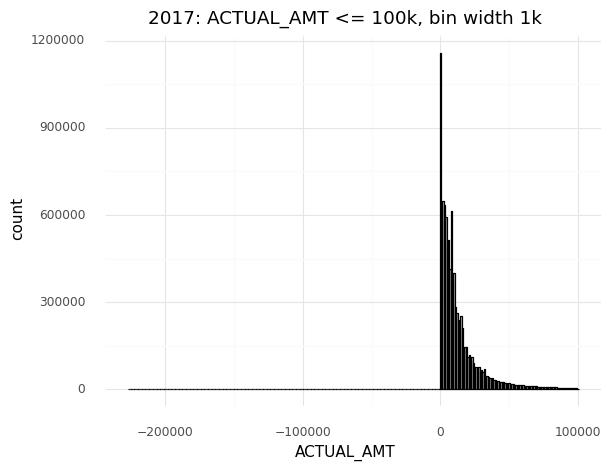

<ggplot: (136405652083)>

In [34]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

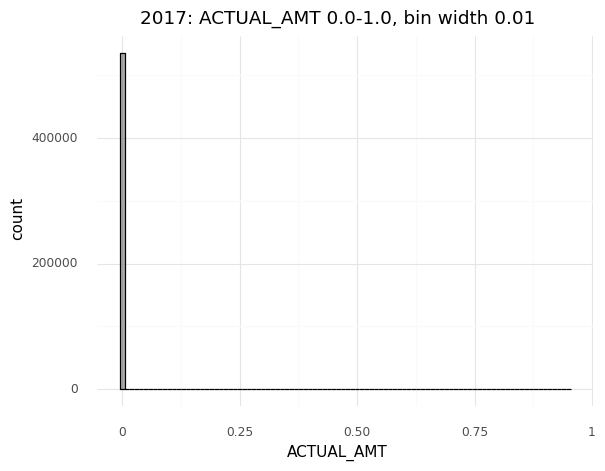

<ggplot: (136239689620)>

In [35]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

<AxesSubplot:>

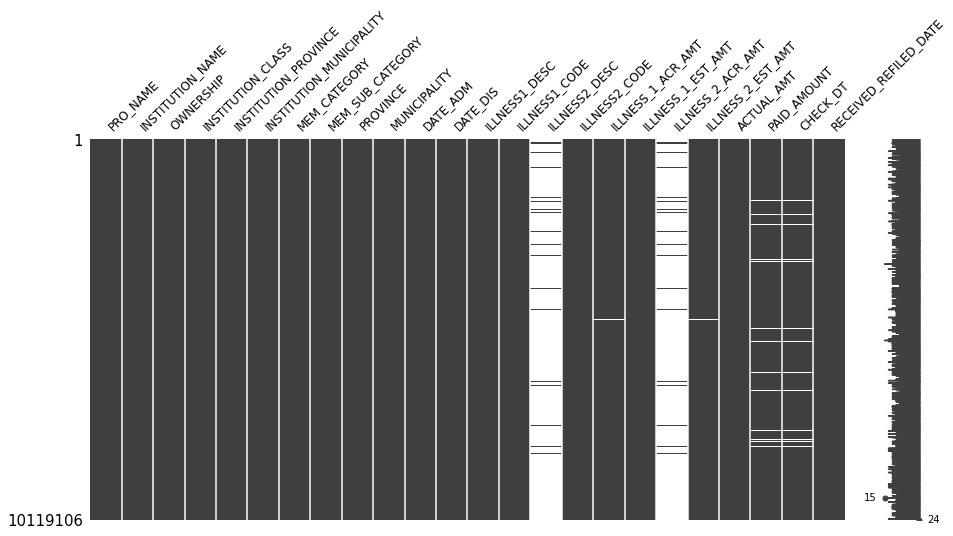

In [36]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

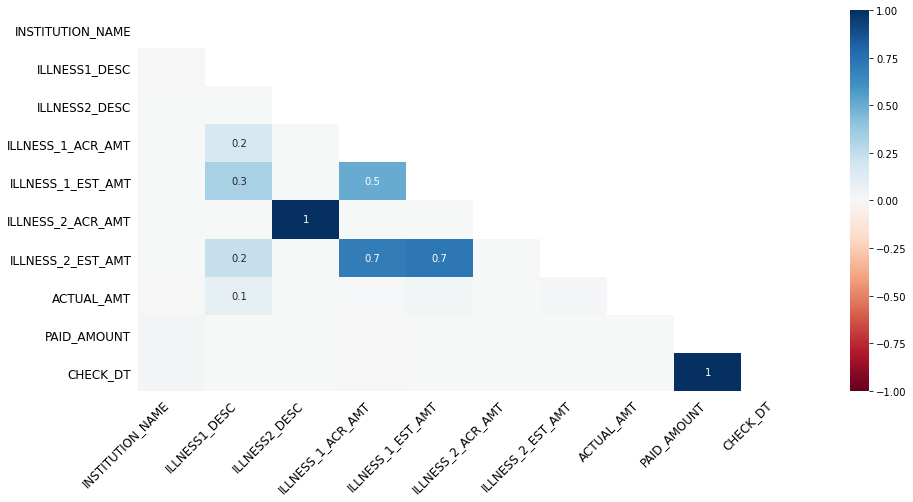

In [37]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

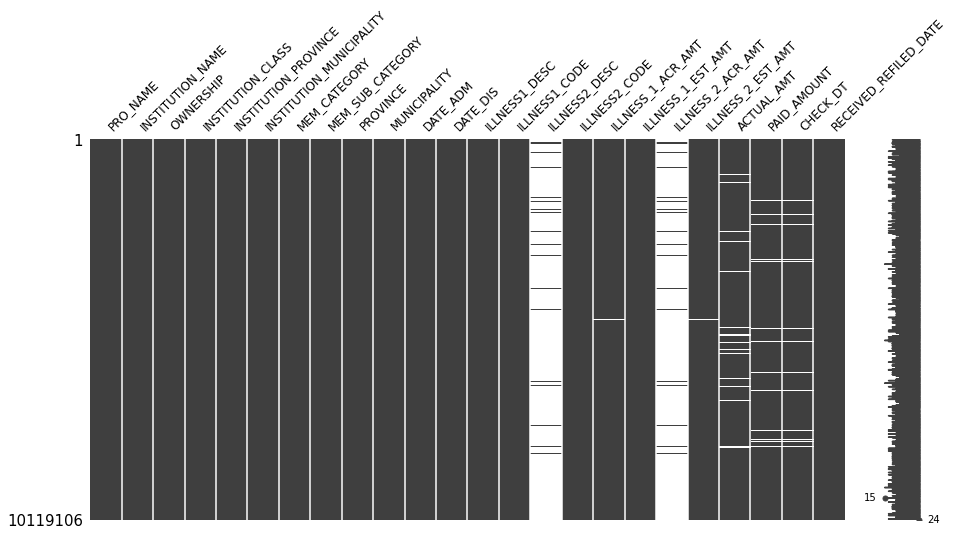

In [38]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

<AxesSubplot:>

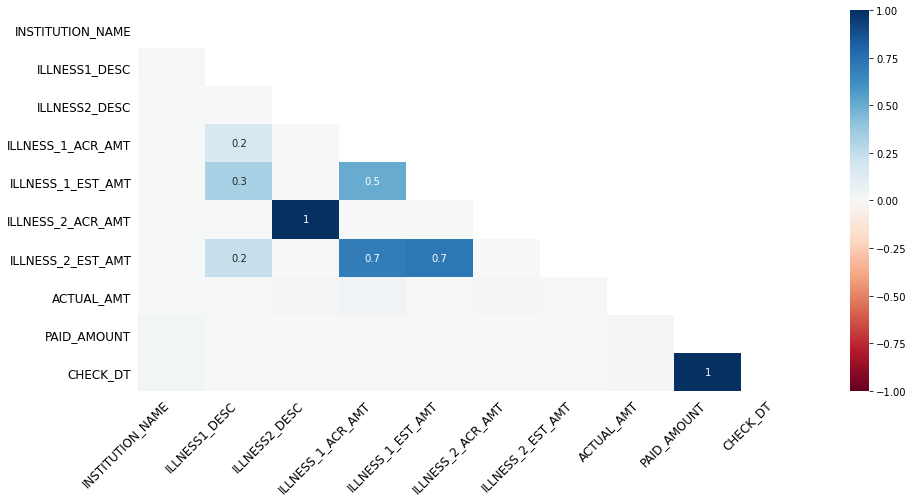

In [39]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [40]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

Unreachable objects: 12859
Remaining Garbage:
[]
Unreachable objects: 0
Remaining Garbage:
[]


# 2018

### Read Input File

In [5]:
year_upd = 2018
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO IVB,OCCIDENTAL MINDORO PROVINCIAL HOSPITAL,PROVINCIAL,LEVEL 1 HOSPITAL,OCCIDENTAL MINDORO,MAMBURAO,INDIGENT,INDIGENT,OCCIDENTAL MINDORO,MAMBURAO,...,NaN,-1,6000.0000,6000.0000,NaN,0.0000,6263.0000,6000.0000,2018-11-09,2018-07-04
1,PRO II,"DE VERA MEDICAL CENTER, INC.",CORPORATE,LEVEL 2 HOSPITAL,ISABELA,SANTIAGO,SPONSORED,SPONSORED,ISABELA,SANTIAGO,...,NaN,-1,16000.0000,16000.0000,NaN,0.0000,112164.5000,16000.0000,2018-12-06,2018-12-01
2,PRO VIII,WESTERN LEYTE PROVINCIAL HOSPITAL,LGU,LEVEL 1 HOSPITAL,LEYTE,BAYBAY,SPONSORED,SPONSORED,LEYTE,BAYBAY,...,NaN,-1,5000.0000,5000.0000,NaN,0.0000,6315.0000,5000.0000,2019-01-10,2018-12-20
3,PRO NCR CENTRAL,QUIRINO MEMORIAL MEDICAL CENTER,DOH,LEVEL 3 HOSPITAL,SECOND DISTRICT,QUEZON CITY,SPONSORED,SPONSORED,SECOND DISTRICT,QUEZON CITY,...,NaN,-1,3640.0000,3640.0000,NaN,0.0000,1490.0000,3640.0000,2018-05-19,2018-03-23
4,PRO IIIA,RAFAEL LAZATIN MEMORIAL MEDICAL CENTER,LGU,LEVEL 1 HOSPITAL,PAMPANGA,ANGELES CITY,INFORMAL ECONOMY,INFORMAL SECTOR,PAMPANGA,ANGELES CITY,...,NaN,-1,2600.0000,2600.0000,NaN,0.0000,2600.0000,2600.0000,2018-06-06,2018-03-01


In [6]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,1,0.0000
1,No. of Rows with ACTUAL_AMT > 10M,401,0.0037
2,No. of Rows with ACTUAL_AMT < 1M,10714312,99.9372
3,No. of Rows with ACTUAL_AMT < 500k,10699024,99.7946
4,No. of Rows with ACTUAL_AMT < 300k,10671697,99.5397
5,No. of Rows with ACTUAL_AMT < 200k,10625701,99.1107
6,No. of Rows with ACTUAL_AMT < 100k,10416324,97.1577
7,No. of Rows with ACTUAL_AMT < 50k,9861610,91.9837
8,No. of Rows with ACTUAL_AMT <= 500,272778,2.5443
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,129320,1.2062


In [7]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [8]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
Unnamed: 0,
0,6263.0000
1,112164.5000
2,6315.0000
3,1490.0000
4,2600.0000


In [9]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [10]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [11]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [12]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [13]:
# write spreadsheets above
writer.save()

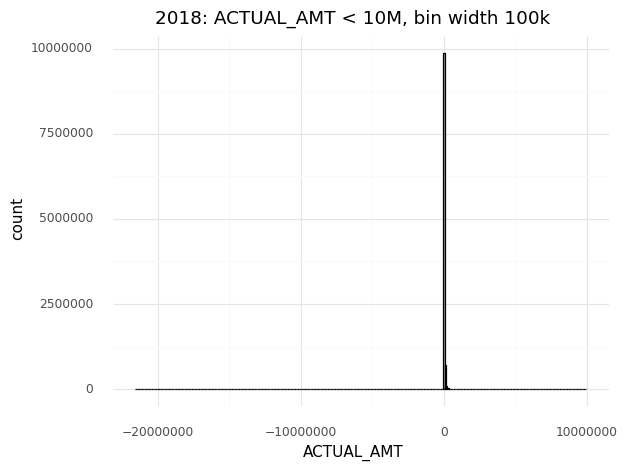

<ggplot: (146063650919)>

In [14]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

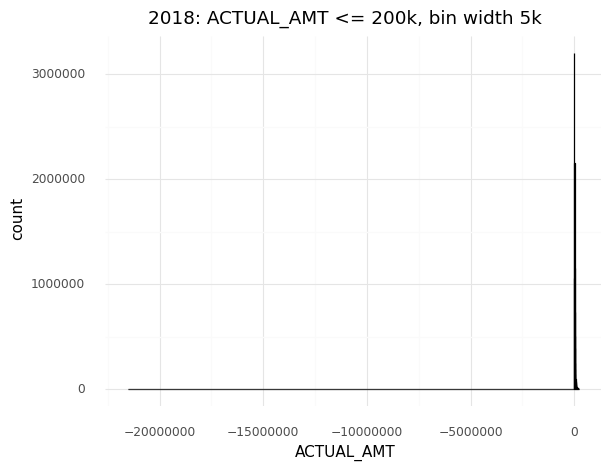

<ggplot: (146063611534)>

In [15]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

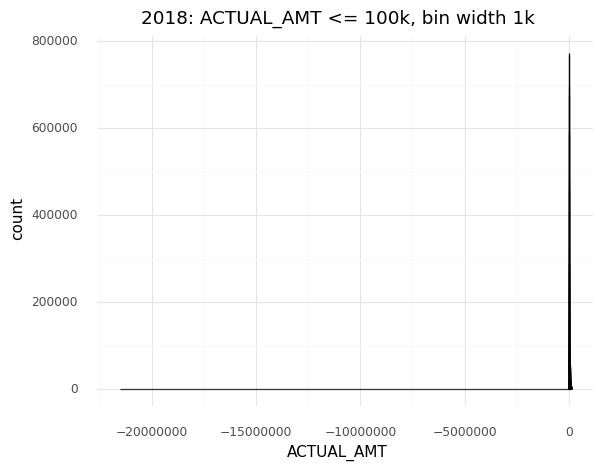

<ggplot: (146063766001)>

In [16]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

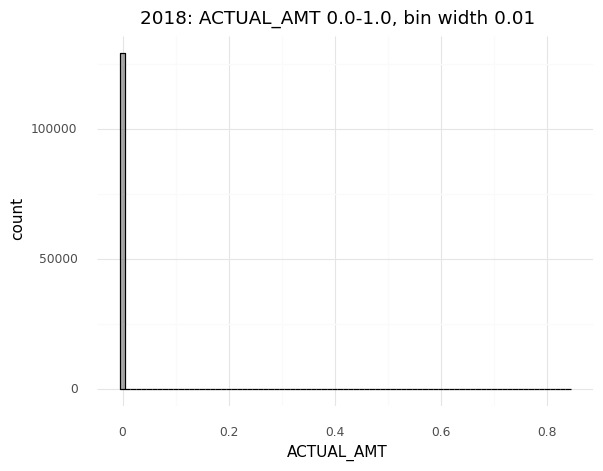

<ggplot: (146063728415)>

In [17]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

<AxesSubplot:>

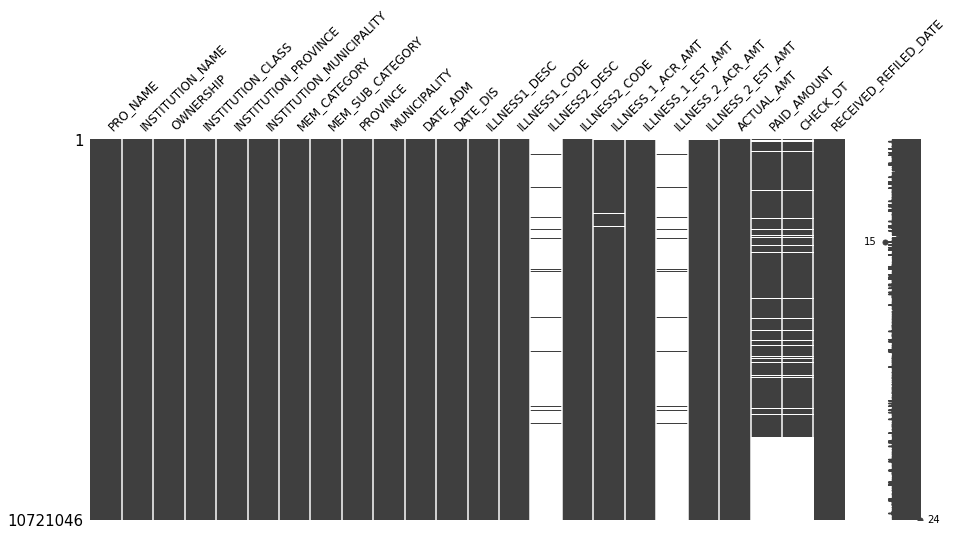

In [18]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

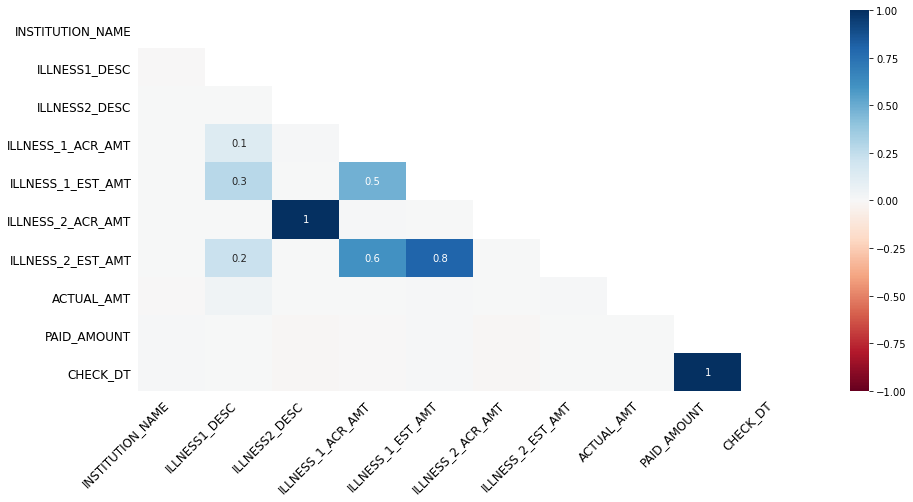

In [19]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

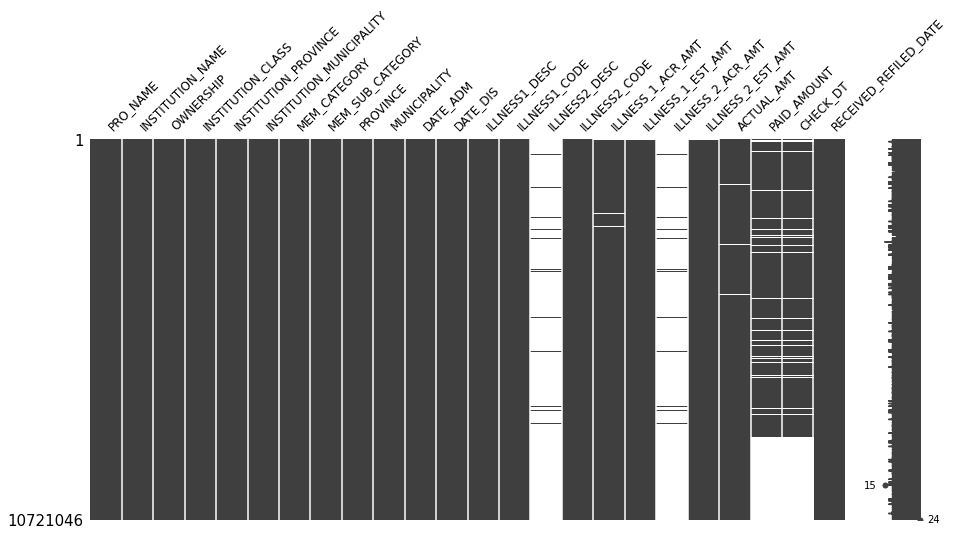

In [20]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

<AxesSubplot:>

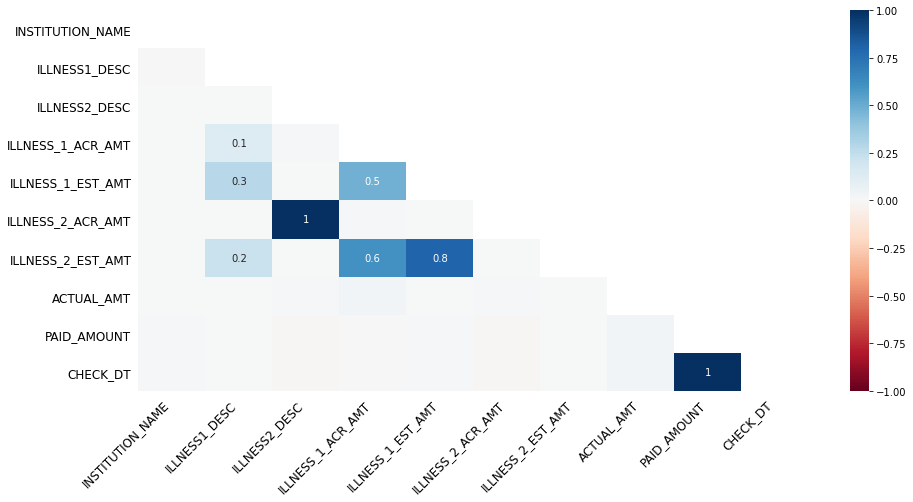

In [21]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [22]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

Unreachable objects: 796
Remaining Garbage:
[]
Unreachable objects: 28073
Remaining Garbage:
[]


# 2019

### Read Input File

In [5]:
year_upd = 2019
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO IIIA,FMC RENALCARE CORP.,CORPORATE,FREE STANDING DIALYSIS CLINIC,TARLAC,CAPAS,SPONSORED,SPONSORED,TARLAC,CAPAS,...,NaN,-1,13000.0000,13000.0000,NaN,0.0000,13000.0000,13000.0000,2019-09-09,2019-08-30
1,PRO IIIA,BATAAN PENINSULA MEDICAL CENTER,SINGLE PROPRIETORSHIP,LEVEL 1 HOSPITAL,BATAAN,DINALUPIHAN,SENIOR CITIZEN,SENIOR CITIZEN,BATAAN,DINALUPIHAN,...,NaN,-1,12079.8000,18000.0000,NaN,0.0000,12999.7500,18000.0000,2019-02-27,2019-02-22
2,PRO IX,WEST METRO MEDICAL CENTER,CORPORATE,LEVEL 2 HOSPITAL,ZAMBOANGA DEL SUR,ZAMBOANGA CITY,LIFETIME MEMBER,LIFETIME MEMBER,ZAMBOANGA DEL SUR,ZAMBOANGA CITY,...,NaN,-1,2600.0000,2600.0000,NaN,0.0000,5600.0000,2600.0000,2019-10-02,2019-09-18
3,PRO XI,DAVAO DOCTORS HOSPITAL,CORPORATE,LEVEL 3 HOSPITAL,DAVAO DEL SUR,DAVAO CITY,FORMAL ECONOMY,PRIVATE,DAVAO DEL SUR,DAVAO CITY,...,NaN,-1,30300.0000,30300.0000,NaN,0.0000,33893.0000,30300.0000,2019-08-08,2019-07-13
4,PRO IIIB,BULACAN MEDICAL CENTER,PROVINCIAL,LEVEL 3 HOSPITAL,BULACAN,MALOLOS CITY,INDIGENT,INDIGENT,BULACAN,MALOLOS CITY,...,NaN,-1,7280.0000,7280.0000,NaN,0.0000,5082.8800,7280.0000,2019-07-19,2019-07-13


In [6]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,6,0.0001
1,No. of Rows with ACTUAL_AMT > 10M,180,0.0017
2,No. of Rows with ACTUAL_AMT < 1M,10895683,99.9489
3,No. of Rows with ACTUAL_AMT < 500k,10880500,99.8096
4,No. of Rows with ACTUAL_AMT < 300k,10852568,99.5534
5,No. of Rows with ACTUAL_AMT < 200k,10803500,99.1033
6,No. of Rows with ACTUAL_AMT < 100k,10581709,97.0688
7,No. of Rows with ACTUAL_AMT < 50k,9989190,91.6334
8,No. of Rows with ACTUAL_AMT <= 500,124189,1.1392
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,96347,0.8838


In [7]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [8]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
Unnamed: 0,
0,13000.0000
1,12999.7500
2,5600.0000
3,33893.0000
4,5082.8800


In [9]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [10]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [11]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [12]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [13]:
# write spreadsheets above
writer.save()

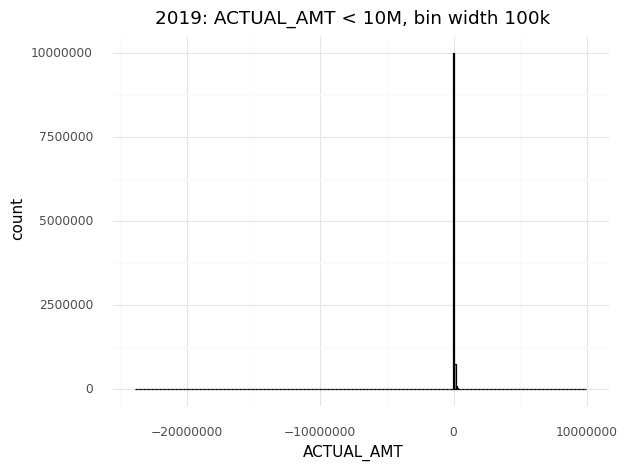

<ggplot: (146063789668)>

In [32]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

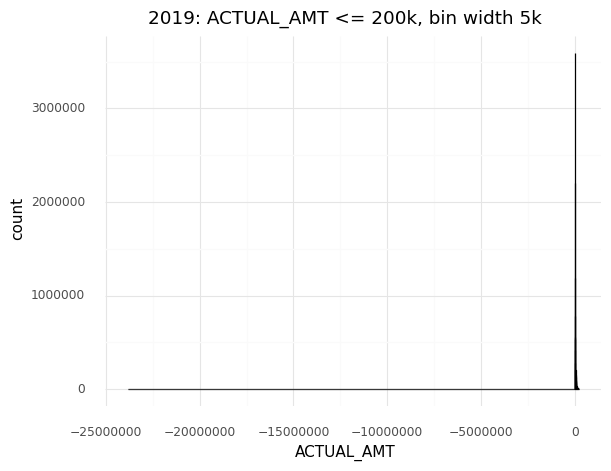

<ggplot: (146148524508)>

In [33]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

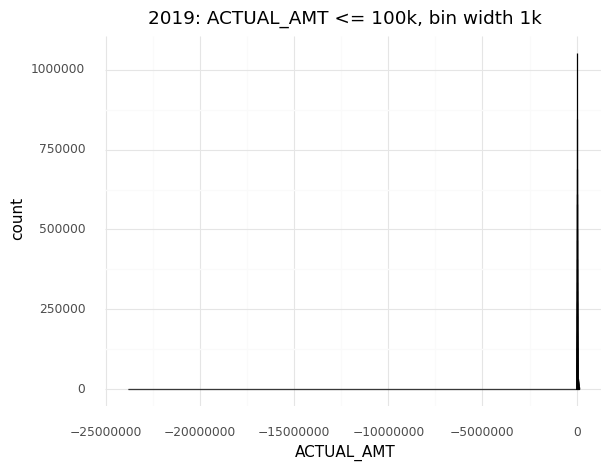

<ggplot: (146148516229)>

In [34]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

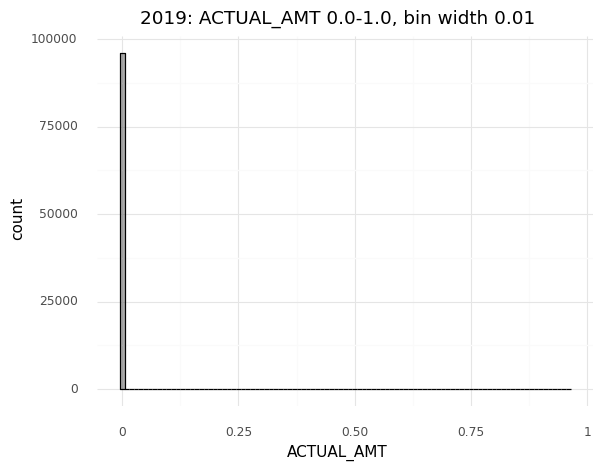

<ggplot: (146063657509)>

In [35]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

<AxesSubplot:>

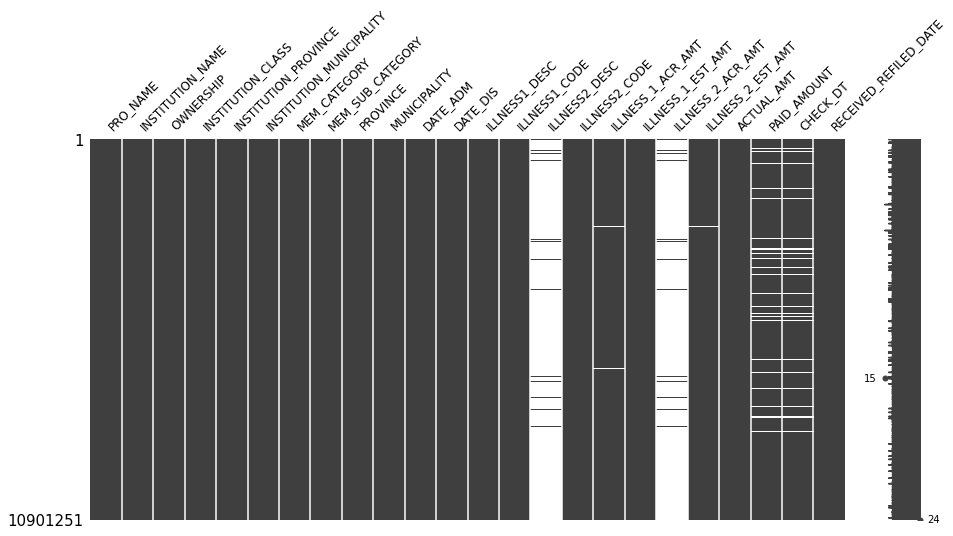

In [36]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

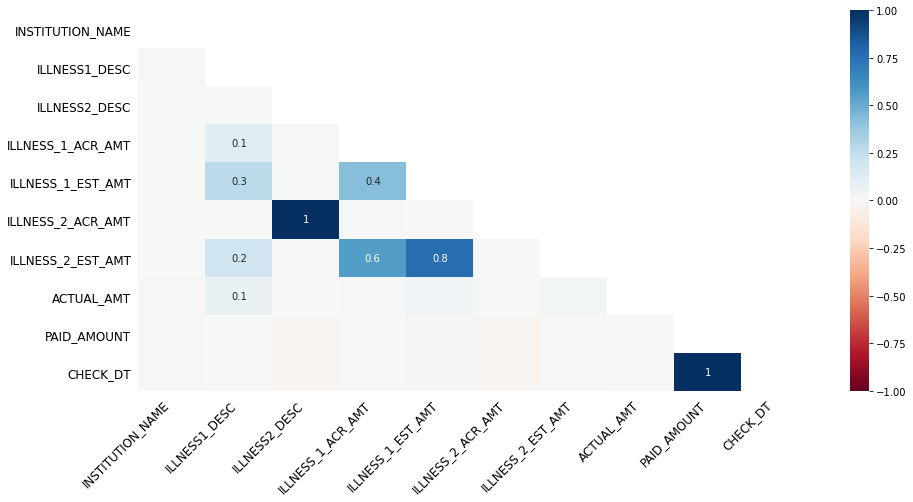

In [37]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

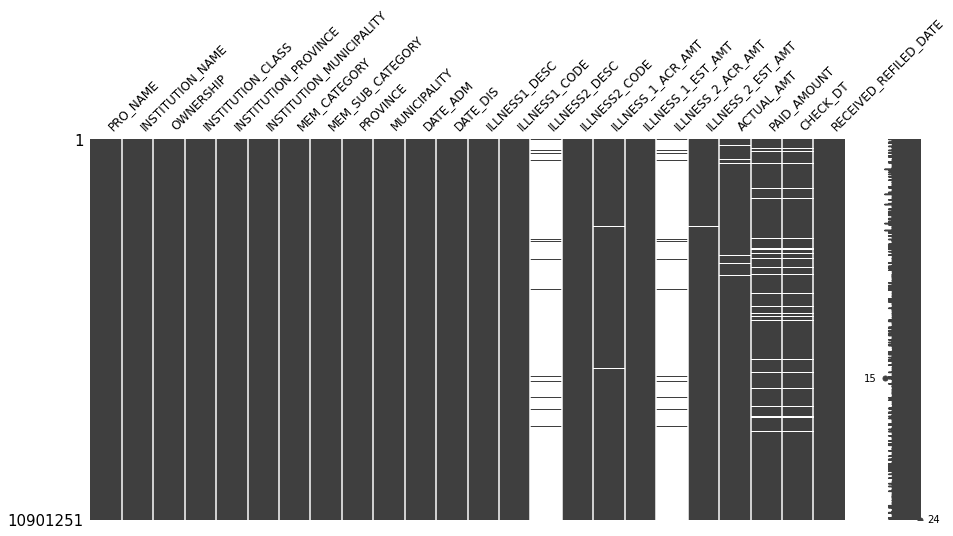

In [7]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

<AxesSubplot:>

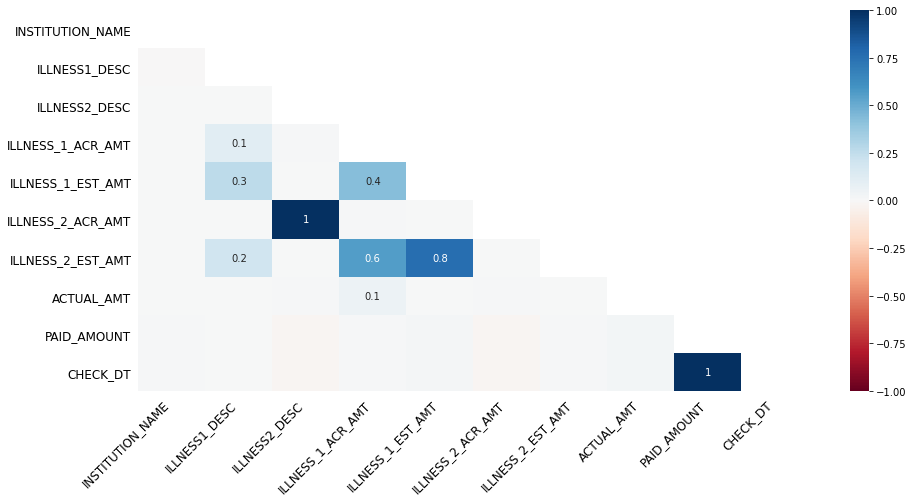

In [39]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [12]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

Unreachable objects: 27
Remaining Garbage:
[]
Unreachable objects: 0
Remaining Garbage:
[]
Unreachable objects: 0
Remaining Garbage:
[]
Unreachable objects: 0
Remaining Garbage:
[]


# 2020

### Read Input File

In [13]:
year_upd = 2020
df1 = pd.read_csv(os.path.join(directory, str(year_upd) + '_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

writer = pd.ExcelWriter(os.path.join(directory, str(year_upd) + '_totals_ACTUAL_AMT.xlsx'), engine='xlsxwriter')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO XII,SOUTH COTABATO PROVINCIAL HOSPITAL,LGU,LEVEL 2 HOSPITAL,SOUTH COTABATO,KORONADAL CITY,INFORMAL ECONOMY,INFORMAL SECTOR,SOUTH COTABATO,KORONADAL CITY,...,NaN,-1,3640.0000,3640.0000,NaN,0.0000,2040.0000,3640.0000,2020-10-13,2020-10-05
1,PRO IIIA,"ST. THERESA DIALYSIS CENTER, INC.",CORPORATE,FREE STANDING DIALYSIS CLINIC,PAMPANGA,CITY OF SAN FERNANDO,INFORMAL ECONOMY,INFORMAL SECTOR,PAMPANGA,CITY OF SAN FERNANDO,...,NaN,-1,7800.0000,7800.0000,NaN,0.0000,13350.0000,7800.0000,2021-04-30,2020-11-24
2,PRO V,LEGAZPI CITY HOSPITAL,LGU,LEVEL 1 HOSPITAL,ALBAY,LEGAZPI CITY,SPONSORED,SPONSORED,ALBAY,LEGAZPI CITY,...,NaN,-1,19000.0000,19000.0000,NaN,0.0000,28777.6800,19000.0000,2020-05-26,2020-04-27
3,PRO XI,DOCTORS COMMUNITY HOSPITAL,SINGLE PROPRIETORSHIP,LEVEL 1 HOSPITAL,COMPOSTELA VALLEY,MAWAB,SENIOR CITIZEN,SENIOR CITIZEN,COMPOSTELA VALLEY,MAWAB,...,NaN,-1,9000.0000,9000.0000,NaN,0.0000,11804.4800,9000.0000,2020-09-17,2020-06-25
4,PRO X,J.R. BORJA GENERAL HOSPITAL,LGU,LEVEL 1 HOSPITAL,MISAMIS ORIENTAL,CAGAYAN DE ORO CITY,INDIGENT,INDIGENT,MISAMIS ORIENTAL,CAGAYAN DE ORO CITY,...,NaN,-1,2950.0000,2950.0000,NaN,0.0000,2959.6900,2750.0000,2020-11-04,2020-09-29


In [14]:
# stats on number of rows with certain ACTUAL_AMT values
total_year = len(df1.index)
total_na = len(df1[df1['ACTUAL_AMT'].isna()])
total_more_10M = len(df1[df1['ACTUAL_AMT'] >= 10000000])
total_less_1M = len(df1[(df1['ACTUAL_AMT'] < 1000000)])
total_less_500k = len(df1[(df1['ACTUAL_AMT'] < 500000)])
total_less_300k = len(df1[(df1['ACTUAL_AMT'] < 300000)])
total_less_200k = len(df1[(df1['ACTUAL_AMT'] < 200000)])
total_less_100k = len(df1[(df1['ACTUAL_AMT'] < 100000)])
total_less_50k = len(df1[(df1['ACTUAL_AMT'] < 50000)])
total_500_or_less = len(df1[(df1['ACTUAL_AMT'] <= 500)])
total_less_0to1 = len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])
total_neg = len(df1[(df1['ACTUAL_AMT'] < 0)])
df_stats = pd.DataFrame([['No. of Rows with No ACTUAL_AMT keyed in', total_na, 100*total_na/total_year],
                        ['No. of Rows with ACTUAL_AMT > 10M', total_more_10M, 100*total_more_10M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 1M', total_less_1M, 100*total_less_1M/total_year],
                        ['No. of Rows with ACTUAL_AMT < 500k', total_less_500k, 100*total_less_500k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 300k', total_less_300k, 100*total_less_300k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 200k', total_less_200k, 100*total_less_200k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 100k', total_less_100k, 100*total_less_100k/total_year],
                        ['No. of Rows with ACTUAL_AMT < 50k', total_less_50k, 100*total_less_50k/total_year],
                        ['No. of Rows with ACTUAL_AMT <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                        ['No. of Rows with ACTUAL_AMT bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                        ['No. of Rows with Negative ACTUAL_AMT', total_neg, 100*total_neg/total_year],
                        ['Total No. of Rows', total_year, 100*total_year/total_year]],
                       columns=['Rows', 'Freq.', 'Percent'])
df_stats.to_excel(writer, sheet_name='ACTUAL_AMT stats')
df_stats

,Rows,Freq.,Percent
0,No. of Rows with No ACTUAL_AMT keyed in,492,0.0049
1,No. of Rows with ACTUAL_AMT > 10M,195,0.0020
2,No. of Rows with ACTUAL_AMT < 1M,9934946,99.9055
3,No. of Rows with ACTUAL_AMT < 500k,9911347,99.6682
4,No. of Rows with ACTUAL_AMT < 300k,9868942,99.2418
5,No. of Rows with ACTUAL_AMT < 200k,9802375,98.5724
6,No. of Rows with ACTUAL_AMT < 100k,9534164,95.8753
7,No. of Rows with ACTUAL_AMT < 50k,8926439,89.7640
8,No. of Rows with ACTUAL_AMT <= 500,96635,0.9718
9,No. of Rows with ACTUAL_AMT bet 0.0-1.0,70731,0.7113


In [15]:
# this lists down the values of the top 20 highest ACTUAL_AMT values
# will have to filter these out because it is causing errors in plotting histograms,
# since the number of bins is determined by the max value / bin width, and the max value
# causes memory overflows
df1[df1['ACTUAL_AMT'] >= 10000000].sort_values(['ACTUAL_AMT'], ascending=False)['ACTUAL_AMT'] \
            .to_frame().head(20) \
            .to_excel(writer, sheet_name='Top 20 ACTUAL_AMT Values')

In [16]:
df2 = df1[(df1['ACTUAL_AMT'] < 10000000) & (~df1['ACTUAL_AMT'].isna())]['ACTUAL_AMT'].to_frame()
df2.head()

,ACTUAL_AMT
Unnamed: 0,
0,2040.0000
1,13350.0000
2,28777.6800
3,11804.4800
4,2959.6900


In [17]:
# just to check which regions key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Region')

In [18]:
# just to check which provinces key in many 0s
group_categs(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'] < 1) & (df1['ACTUAL_AMT'] >= 0)])) \
        .to_excel(writer, sheet_name='No of 0-1s ACTUAL_AMT by Prov')

In [19]:
# just to check which regions key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'PRO_NAME',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Region')

In [20]:
# just to check which provinces key in many NaN
group_categs(df1[(df1['ACTUAL_AMT'].isna())],
             'INSTITUTION_PROVINCE',
             'region',
            len(df1[(df1['ACTUAL_AMT'].isna())])) \
        .to_excel(writer, sheet_name='No of NaN ACTUAL_AMT by Prov')

In [21]:
# write spreadsheets above
writer.save()

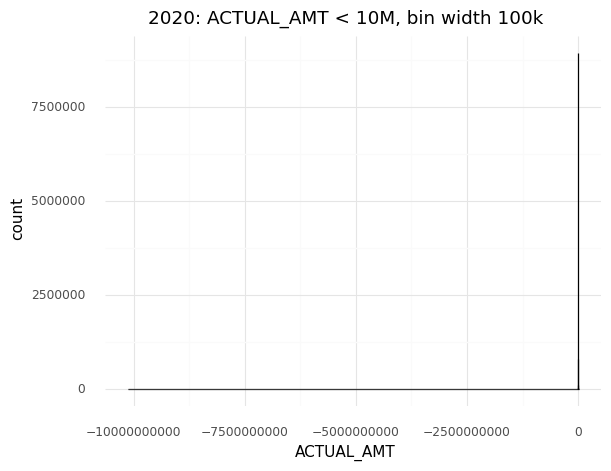

<ggplot: (140626012124)>

In [22]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
# Plot ALL values, with binwidth = 100000 (ACTUAL_AMT = 100k increments per bin)
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=100000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT < 10M, bin width 100k') \
    + theme_minimal()

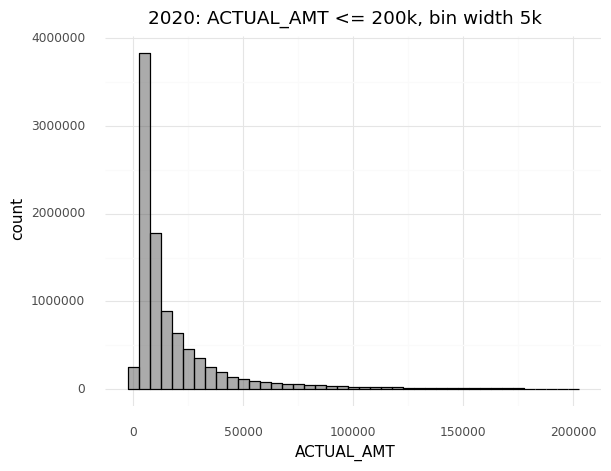

<ggplot: (140623934052)>

In [26]:
# since most of the amounts are in the >200k range, we then re-plot the histogram, 
# this time including amounts within those range

# due to errors in binning (extreme negative value causing run issues),
# opted to just remove it instead
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 200000) & (df2['ACTUAL_AMT'] > 0)])
p + geom_histogram(binwidth=5000, 
#                    fill='blue',     # fill color
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 200k, bin width 5k') \
    + theme_minimal()

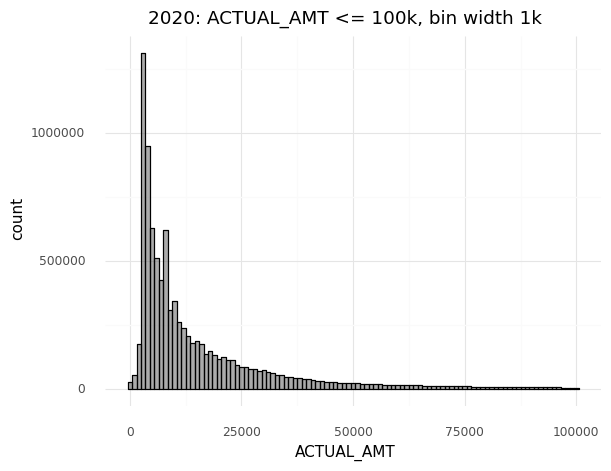

<ggplot: (140626033279)>

In [27]:
# re-plotting the histogram, 
# this time including amounts from 0-100k range, bin width set to 1k value

# due to errors in binning (extreme negative value causing run issues),
# opted to just remove it instead
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] <= 100000) & (df2['ACTUAL_AMT'] > 0)])
p + geom_histogram(binwidth=1000, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT <= 100k, bin width 1k') \
    + theme_minimal()

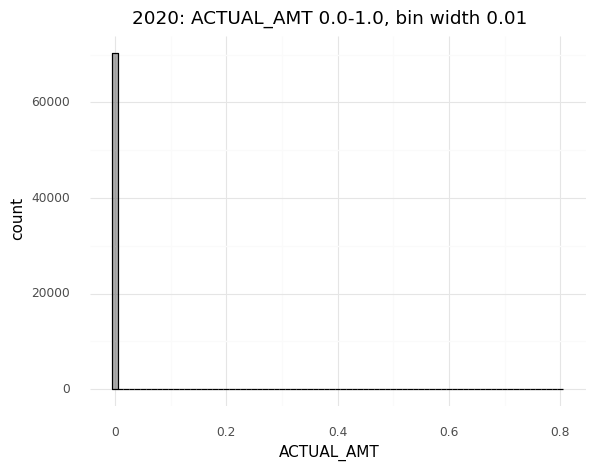

<ggplot: (140714771658)>

In [28]:
# plotting amounts within 0-1 range
p = ggplot(aes(x='ACTUAL_AMT'), data=df2[(df2['ACTUAL_AMT'] < 1) & (df2['ACTUAL_AMT'] >= 0)])
p + geom_histogram(binwidth=0.01, 
#                    fill='blue',     # fill color
                   colour='black', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(str(year_upd) + ': ACTUAL_AMT 0.0-1.0, bin width 0.01') \
    + theme_minimal()

<AxesSubplot:>

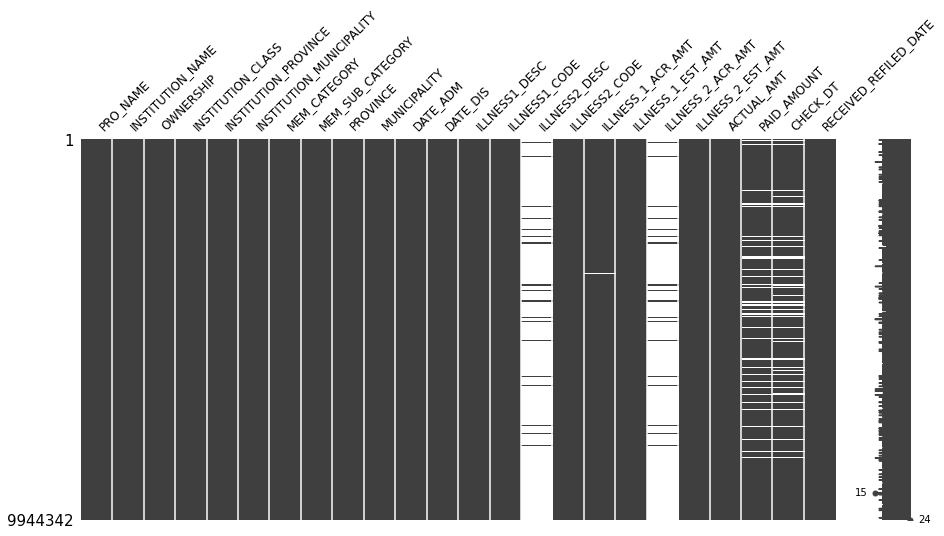

In [29]:
# mapping missing values first (NaN values only)
# ref https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.matrix(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

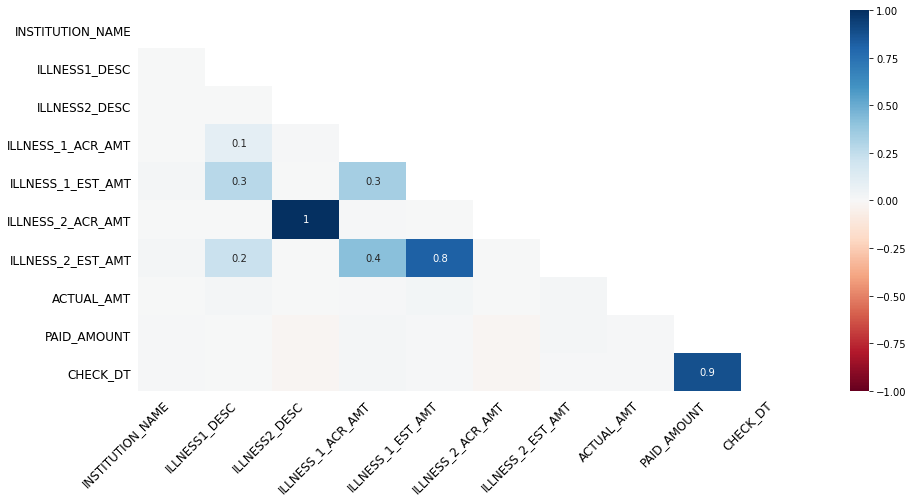

In [30]:
# mapping missing values first (NaN values only)
msno.heatmap(df1, figsize=(15,7), fontsize=12)

<AxesSubplot:>

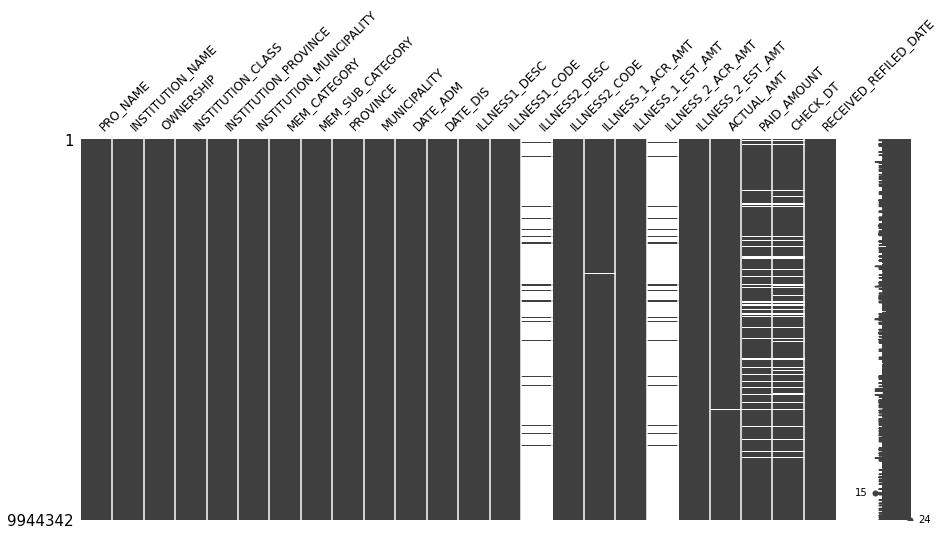

In [31]:
# mapping missing values, setting 0 values as NaN as well
df3 = df1
df3.loc[(df3['ACTUAL_AMT'] < 1) & (df3['ACTUAL_AMT'] >= 0),['ACTUAL_AMT']] = np.nan
msno.matrix(df3, figsize=(15,7), fontsize=12)

<AxesSubplot:>

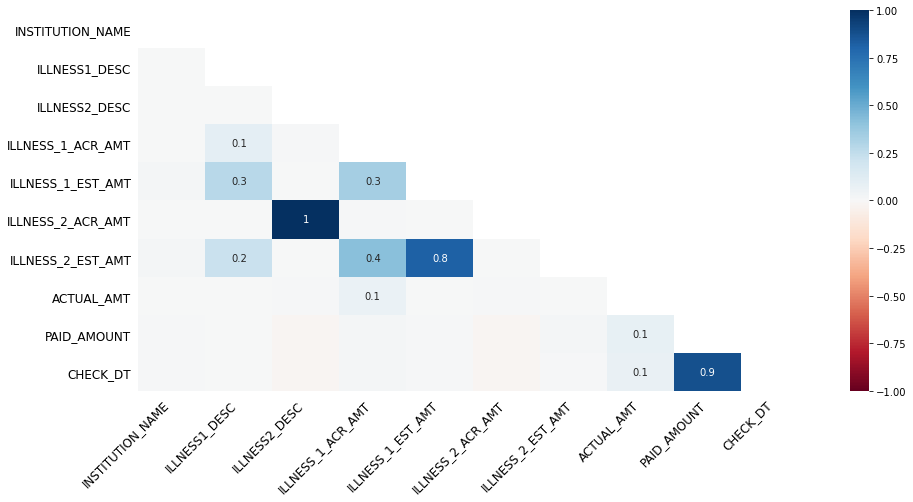

In [32]:
# mapping missing values, setting 0 values as NaN as well
msno.heatmap(df3, figsize=(15,7), fontsize=12)

In [33]:
# clear dataframes before next runs
del[df1, df2, df3, df_stats]
garbage_collector()

Unreachable objects: 9678
Remaining Garbage:
[]
Unreachable objects: 0
Remaining Garbage:
[]
Unreachable objects: 0
Remaining Garbage:
[]
Unreachable objects: 0
Remaining Garbage:
[]
